Make sure modules reload:

In [1]:
%load_ext autoreload
%autoreload 2

Results and progress files are stored in a directory. Simulations (after potentially changing some parameters etc) are restarted from them and update them:

In [46]:
outputFolderName="notebooks/example_evo"
from run_main import run

To start from scratch remove the directory:

In [47]:
!rm -rf notebooks/example_evo

/bin/bash: /home/adam/miniconda3/envs/celoc_env/lib/libtinfo.so.6: no version information available (required by /bin/bash)


Some basic parameters are passed as command line arguments which are stored in a python dict object:

In [48]:
args = dict(
    simduration=60, #duration of simulation run
    simtransient=0, #transient of simulation run
    popSize=36, #population size for optimization
    modelFolder="Worm2D", #folder containing the compiled C++ binary code
    outputFolderName=outputFolderName, #output folder
    overwrite=True, #allow overwrite of output folder 
    checkPointInterval=5, #write the checkpoint file every five generations 
    doOrigMuscInput=False, #use standardized muscle connecitiviy
    doOrigSRInput=False, #use standardized stretch receptors 
    randInitState=False, #use fixed initial conditions
    doTestRun=True, #run a single simple simulation
)

Parameters can be added to the args dict object in the standard python way. Here 'doEvol' tells us to run an optimization using the genetic algorithm. 'maxGens' tells us how many generations to run. Evolutions start from existing parameter files in the directory, so it is possible to run a few generations, examine results and then restart from the final state if the model does not seem to be optimized as desired. This also includes potentially changing optimization parameters and functions. The 'popSize' is the number of individual phenotypes simulated in a single generation. Simulations are performed in parallel so it is sensible to set this parameter to at least the number of cpu cores you have available. 'modelName' tells us which worm model to run. There are several 'hard-coded', 'supplied' models, including 'W2D18', 'W2D21', and 'W2DCE'. These perform simulations of existing published c.elegans models which employ the worm body simulation utilized here. These models include particular configurations of cells, ventral nerve cord, nervous system to muscle connectivity and stretch receptors etc. Parameters are further fine tuned by the genetic algorithm. Once a simulation is run with one of them, a JSON parameter file is created in the directory. The JSON file contains all the model and evolutionary algorithm parameters. If desired further simulations can start from the generic 'W2DSR' model which is initialized entirely from the JSON parameter file. This enables users to configure all aspects of the model, including adding and removing cells, changing parameters and connectivity, selecting which parameters will be 'evolvable' via the genetic algorithm, as well as particulars of the optimization and sensory environment etc. Here we are starting with the 'W2D18' model. 'evoType' selects the particular optimization function to utilize. Different optimization functions select for different properties, such as locomotion speed, oscillation frequency, movement up a chemical gradient etc. The command 'run(**args)' starts the simulation and evolves the current worm model for a further 10 (maxGens) generations every time it is run. 

Further generations to be added: 10
Directory 'notebooks/example_evo' created successfully.
['Worm2D/main_osc', '--randomInitialState', '0', '--doOrigMuscInput', '0', '--doOrigSRInput', '0', '--doTestRun', '1', '-R', '124115', '-p', '36', '-d', '50', '-t', '10', '--maxgens', '10', '-sd', '60', '-st', '0', '--doevol', '1', '-cpt', '5', '--dorandinit', '0', '--donml', '0', '--folder', 'notebooks/example_evo', '--modelname', 'W2D18', '--domusc', '0', '-docpt', '1', '--evoType', 'Evo18']
evotype Evo18
docpt 1
const from default with size 30
jsonfile notebooks/example_evo/worm_data_evo.json
jsonfile notebooks/example_evo/worm_data_evo.json
simrandseed 124115
running simulation sim

Loading activity data from: notebooks/example_evo/act.dat
Loading curvature data from: notebooks/example_evo/curv.dat
Loading body position data from: notebooks/example_evo/body.dat
Saved plot image to: notebooks/example_evo/ExampleActivity.png
Simulation
0.0
60.0
120.0
180.0
240.0
300.0
cell ind is  0
cell ind i

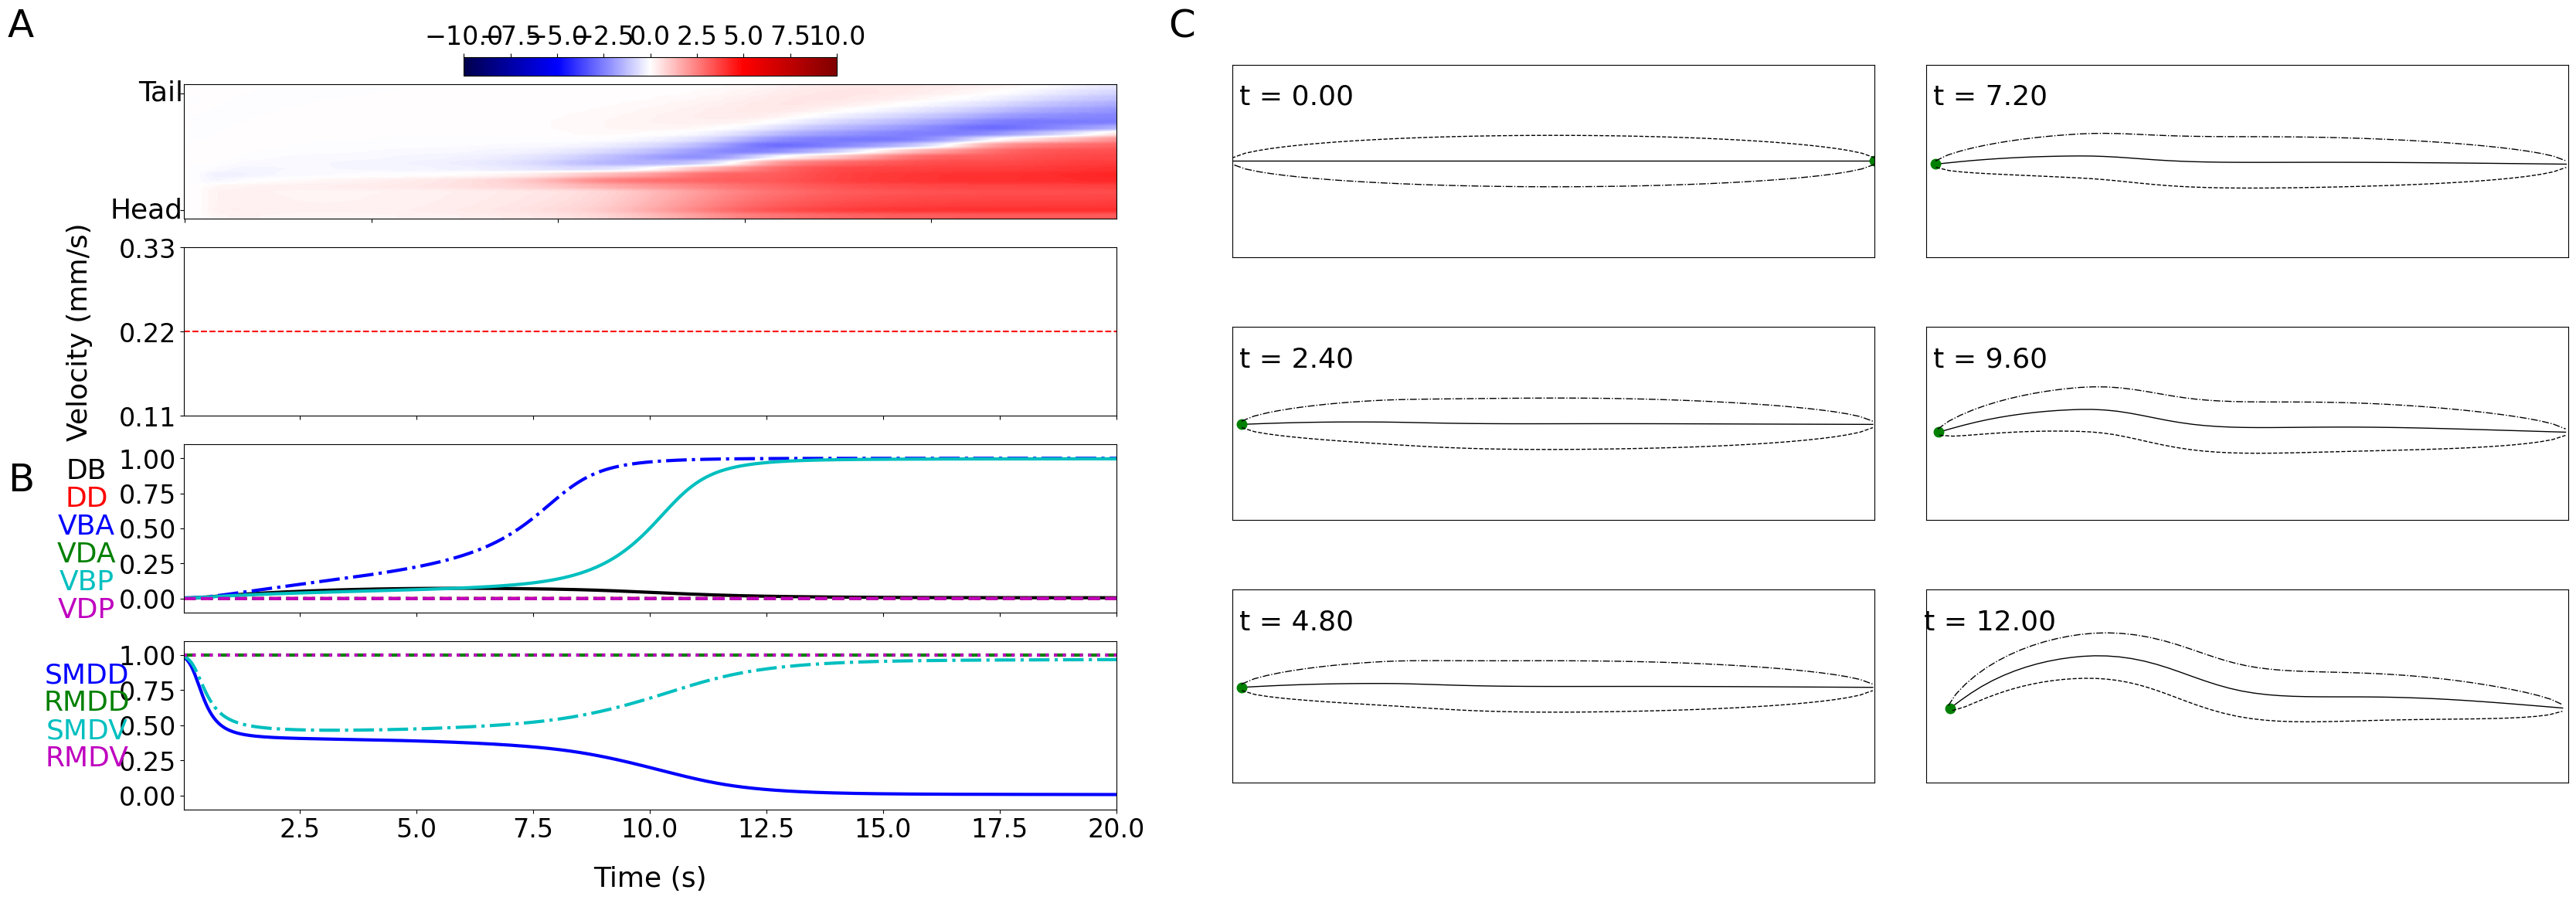

In [30]:
args['RandSeed']=124115 #if random seed is not set, one will be generated
args['doEvol']=True #perform the optimization before running the simulation
args['maxGens']=10 #run the optimization for ten more generations 
args['popSize']=36, #population size for optimization
args['modelName']="W2D18" #the initial code generated model
args['evoType']="Evo18", #the optimization function
print('Further generations to be added: ' + str(args['maxGens']))
run(**args)

Show the fitness of the best phenotype, population fitness and std of population fitness for generations:

In [45]:
with open(outputFolderName + '/fitness.dat') as f:
    print(f.read())

0.0 0.01055980527 0.0009559844353 5.274020108e-06
1.0 0.01515311929 0.002137501642 2.073266561e-05
2.0 0.01515311929 0.002322064762 1.947743753e-05
3.0 0.01515311929 0.00218319262 1.817128258e-05
4.0 0.01638248313 0.002310174648 2.139974213e-05
5.0 0.02098776187 0.003755501112 3.474380578e-05
6.0 0.02098776187 0.003777485143 3.852427487e-05
7.0 0.02098776187 0.003800338197 4.395247758e-05
8.0 0.02142046216 0.003368935694 3.723511827e-05
9.0 0.03026196075 0.004511301829 5.618112698e-05
10.0 0.03106369327 0.004199277497 6.618588678e-05
11.0 0.03106369327 0.004199277497 6.618588678e-05
12.0 0.03106369327 0.005330728035 7.747800571e-05
13.0 0.03106369327 0.005550170133 5.999586334e-05
14.0 0.03106369327 0.005346555604 5.800712189e-05
15.0 0.03106369327 0.004512083542 5.634015195e-05
16.0 0.0312354404 0.006124305513 7.177143513e-05
17.0 0.0312354404 0.006421535284 5.654175256e-05
18.0 0.0312354404 0.005909067265 6.543875925e-05
19.0 0.0312354404 0.007665918578 9.100194352e-05
20.0 0.0312354

Display time series of simulation results of current best phenotype:

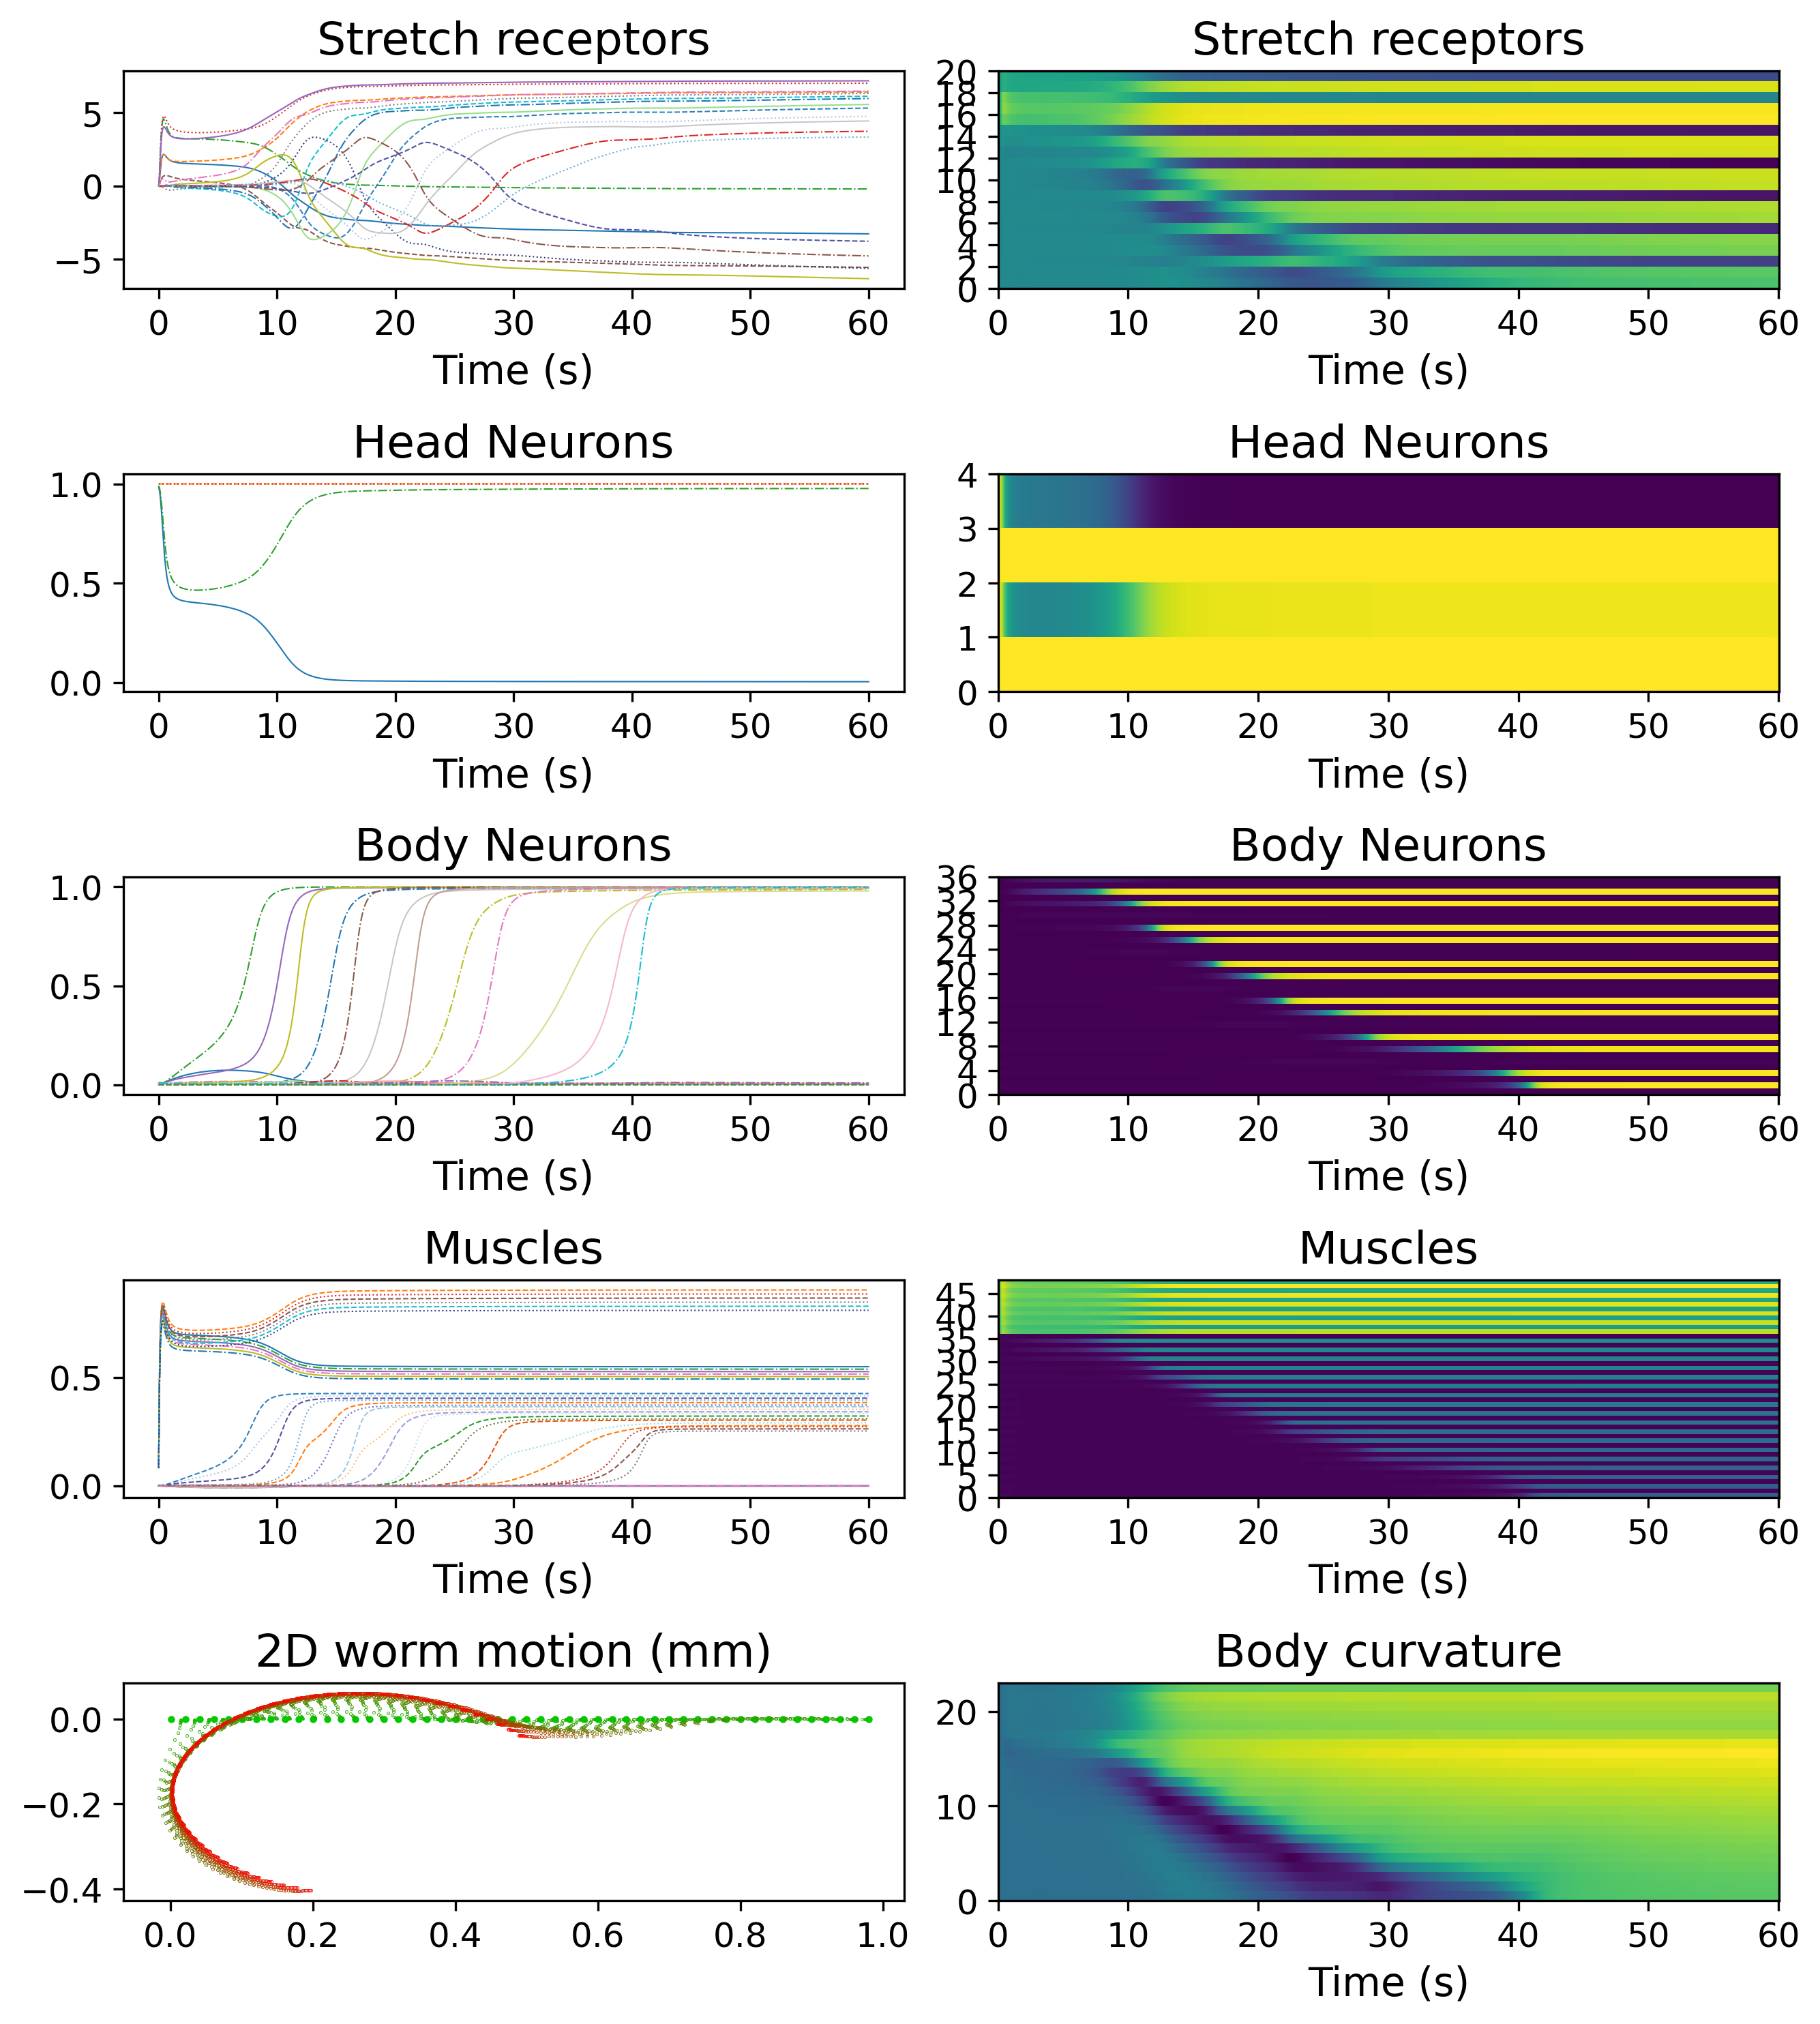

In [32]:
from IPython.display import Image, JSON
Image(filename=outputFolderName + '/ExampleActivity.png')

Display worm motion in larger plot:

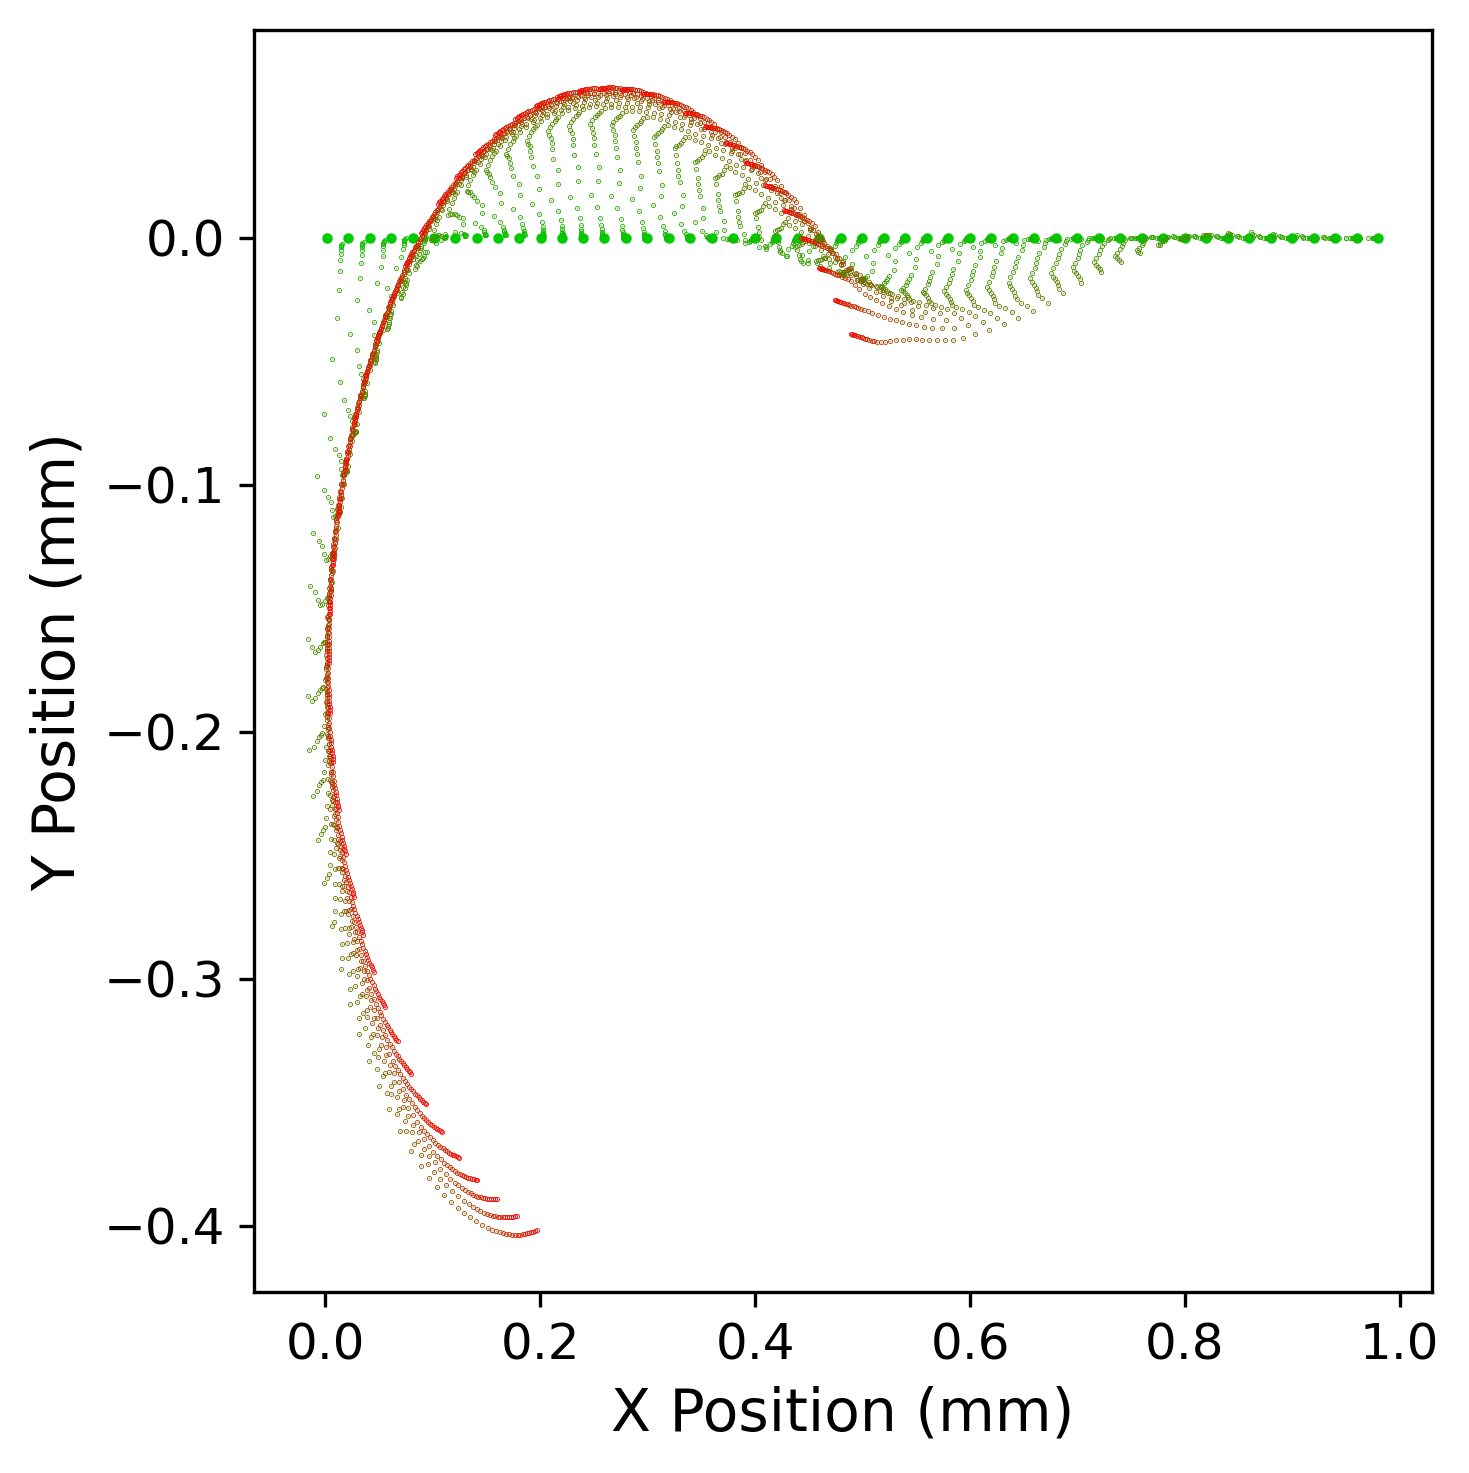

In [33]:
Image(filename=outputFolderName + '/Motion.png')

Plot the evolution history for all the evolvable parameters:

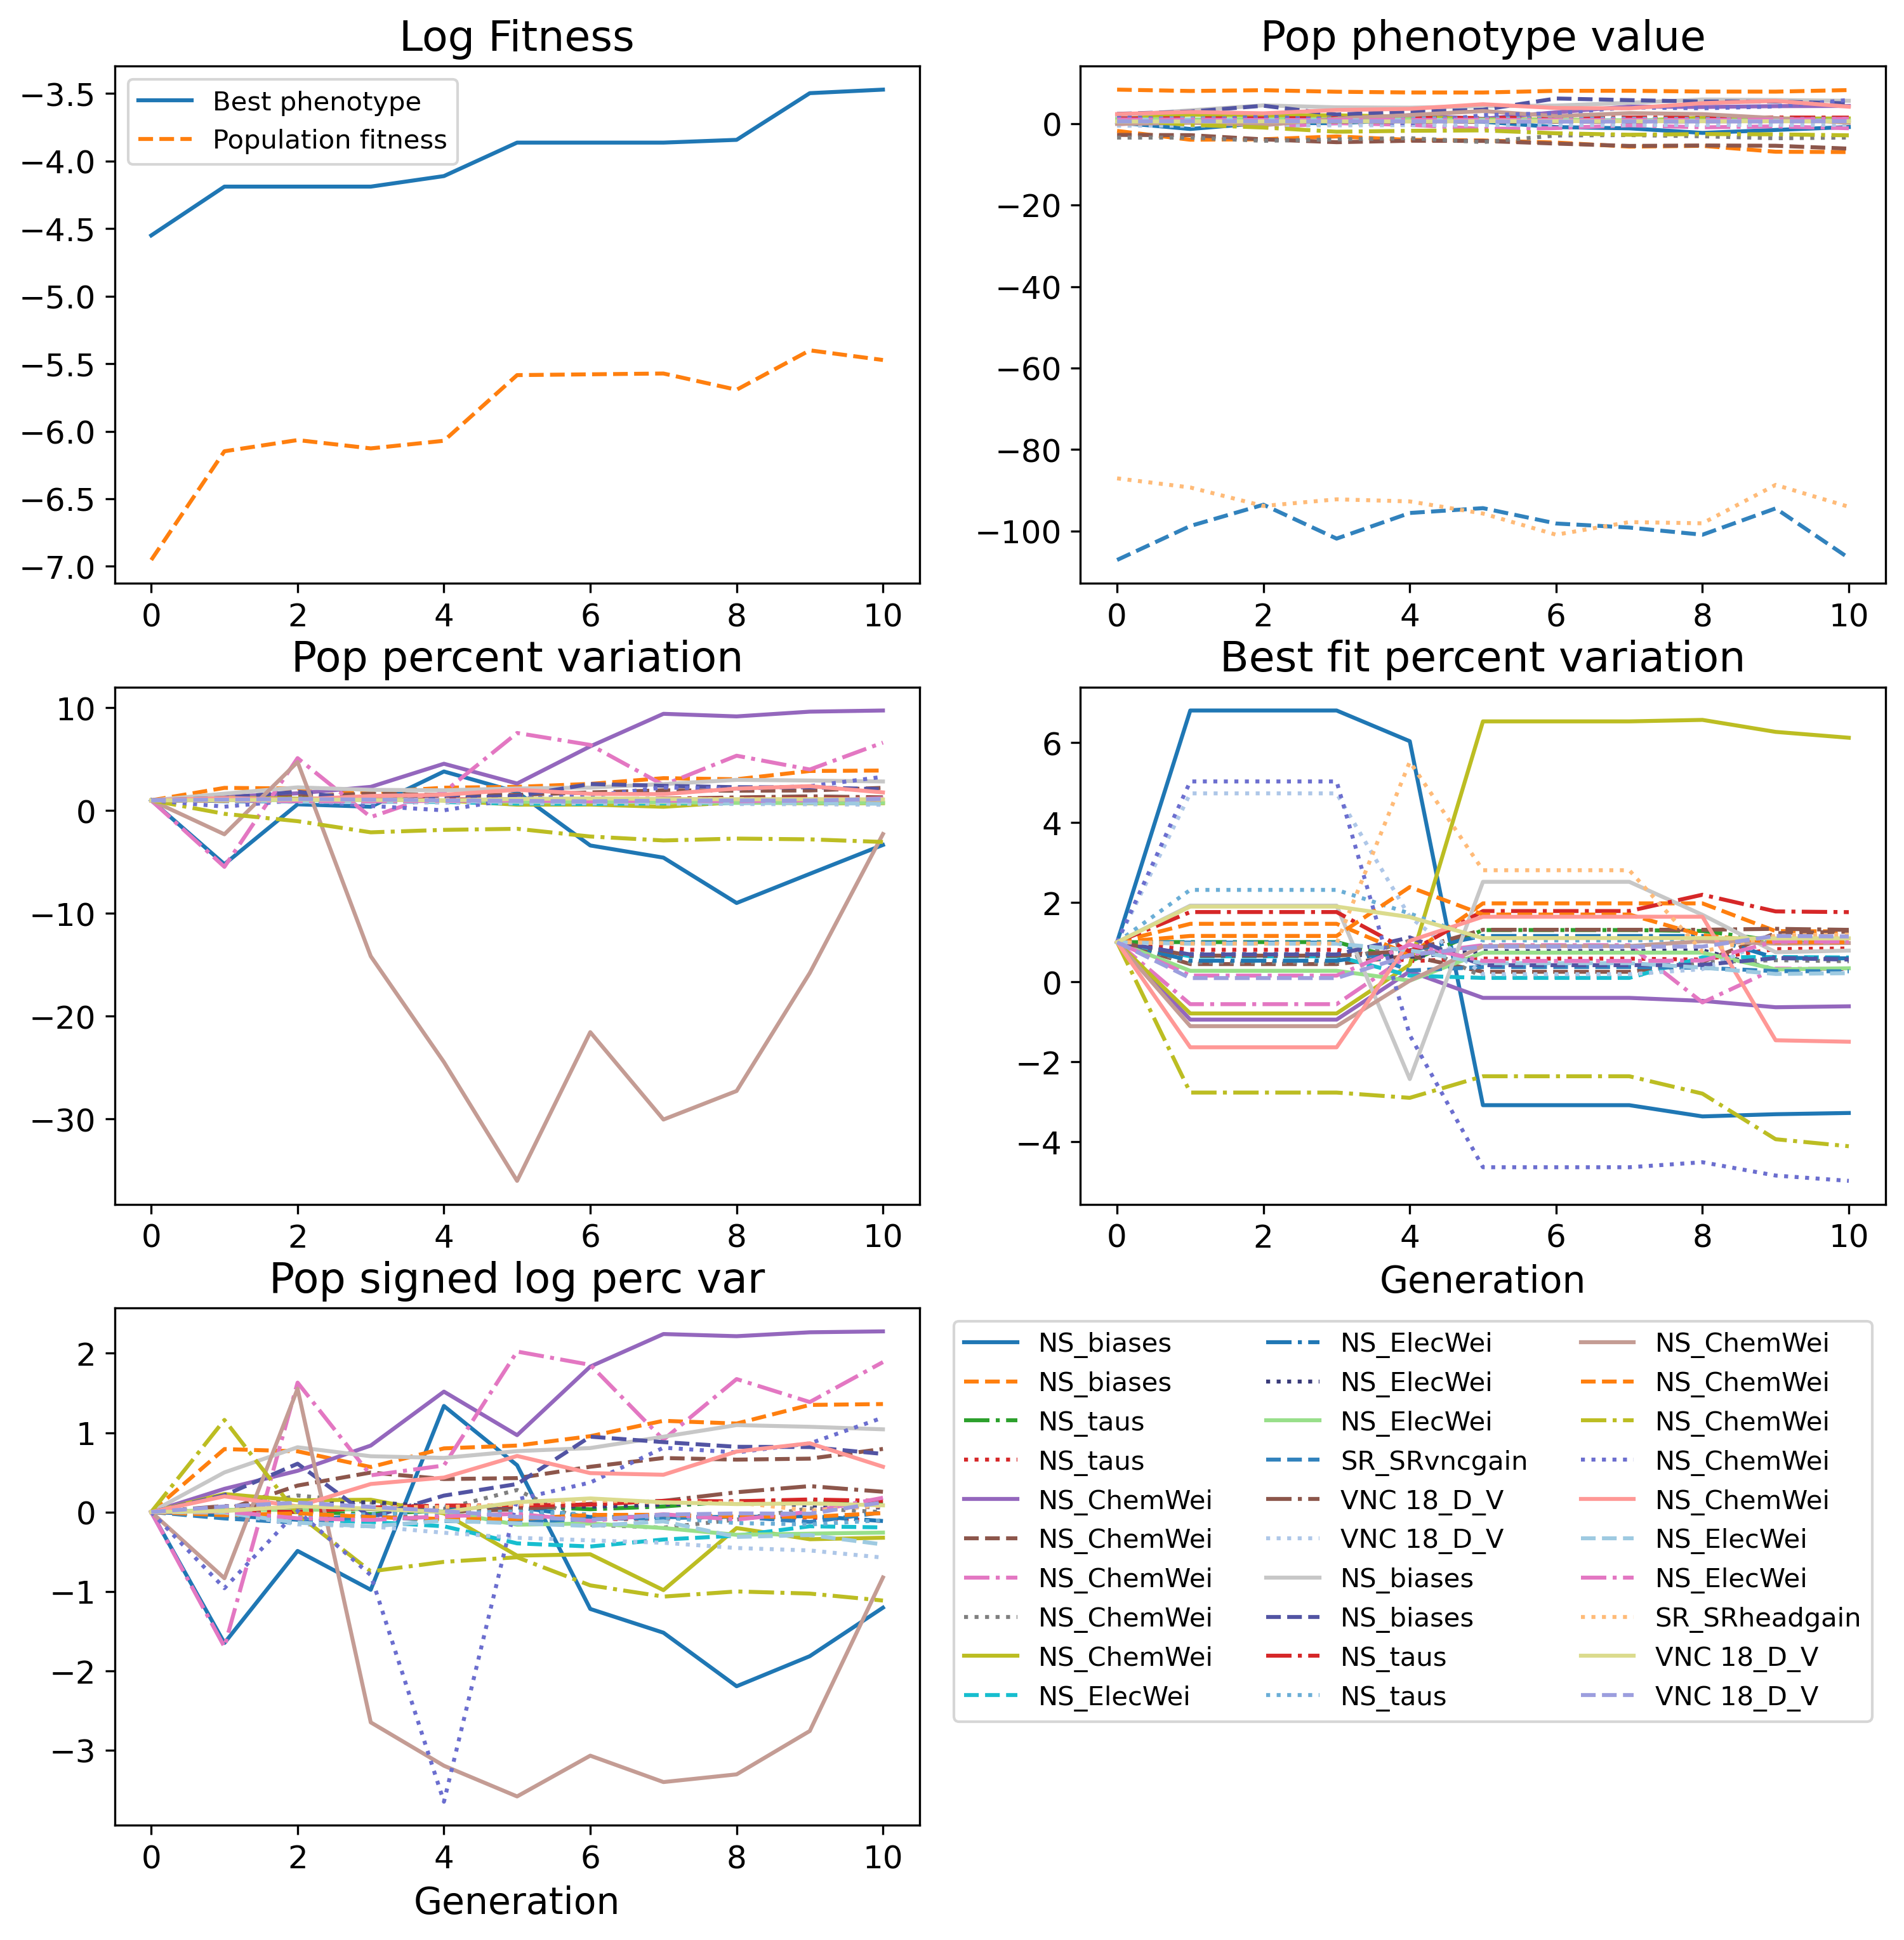

In [34]:
from IPython.display import Image, JSON
Image(filename=outputFolderName + '/Gridfig.png')

Plot the evolution history for evolvable parameters averaged into similar type classes:

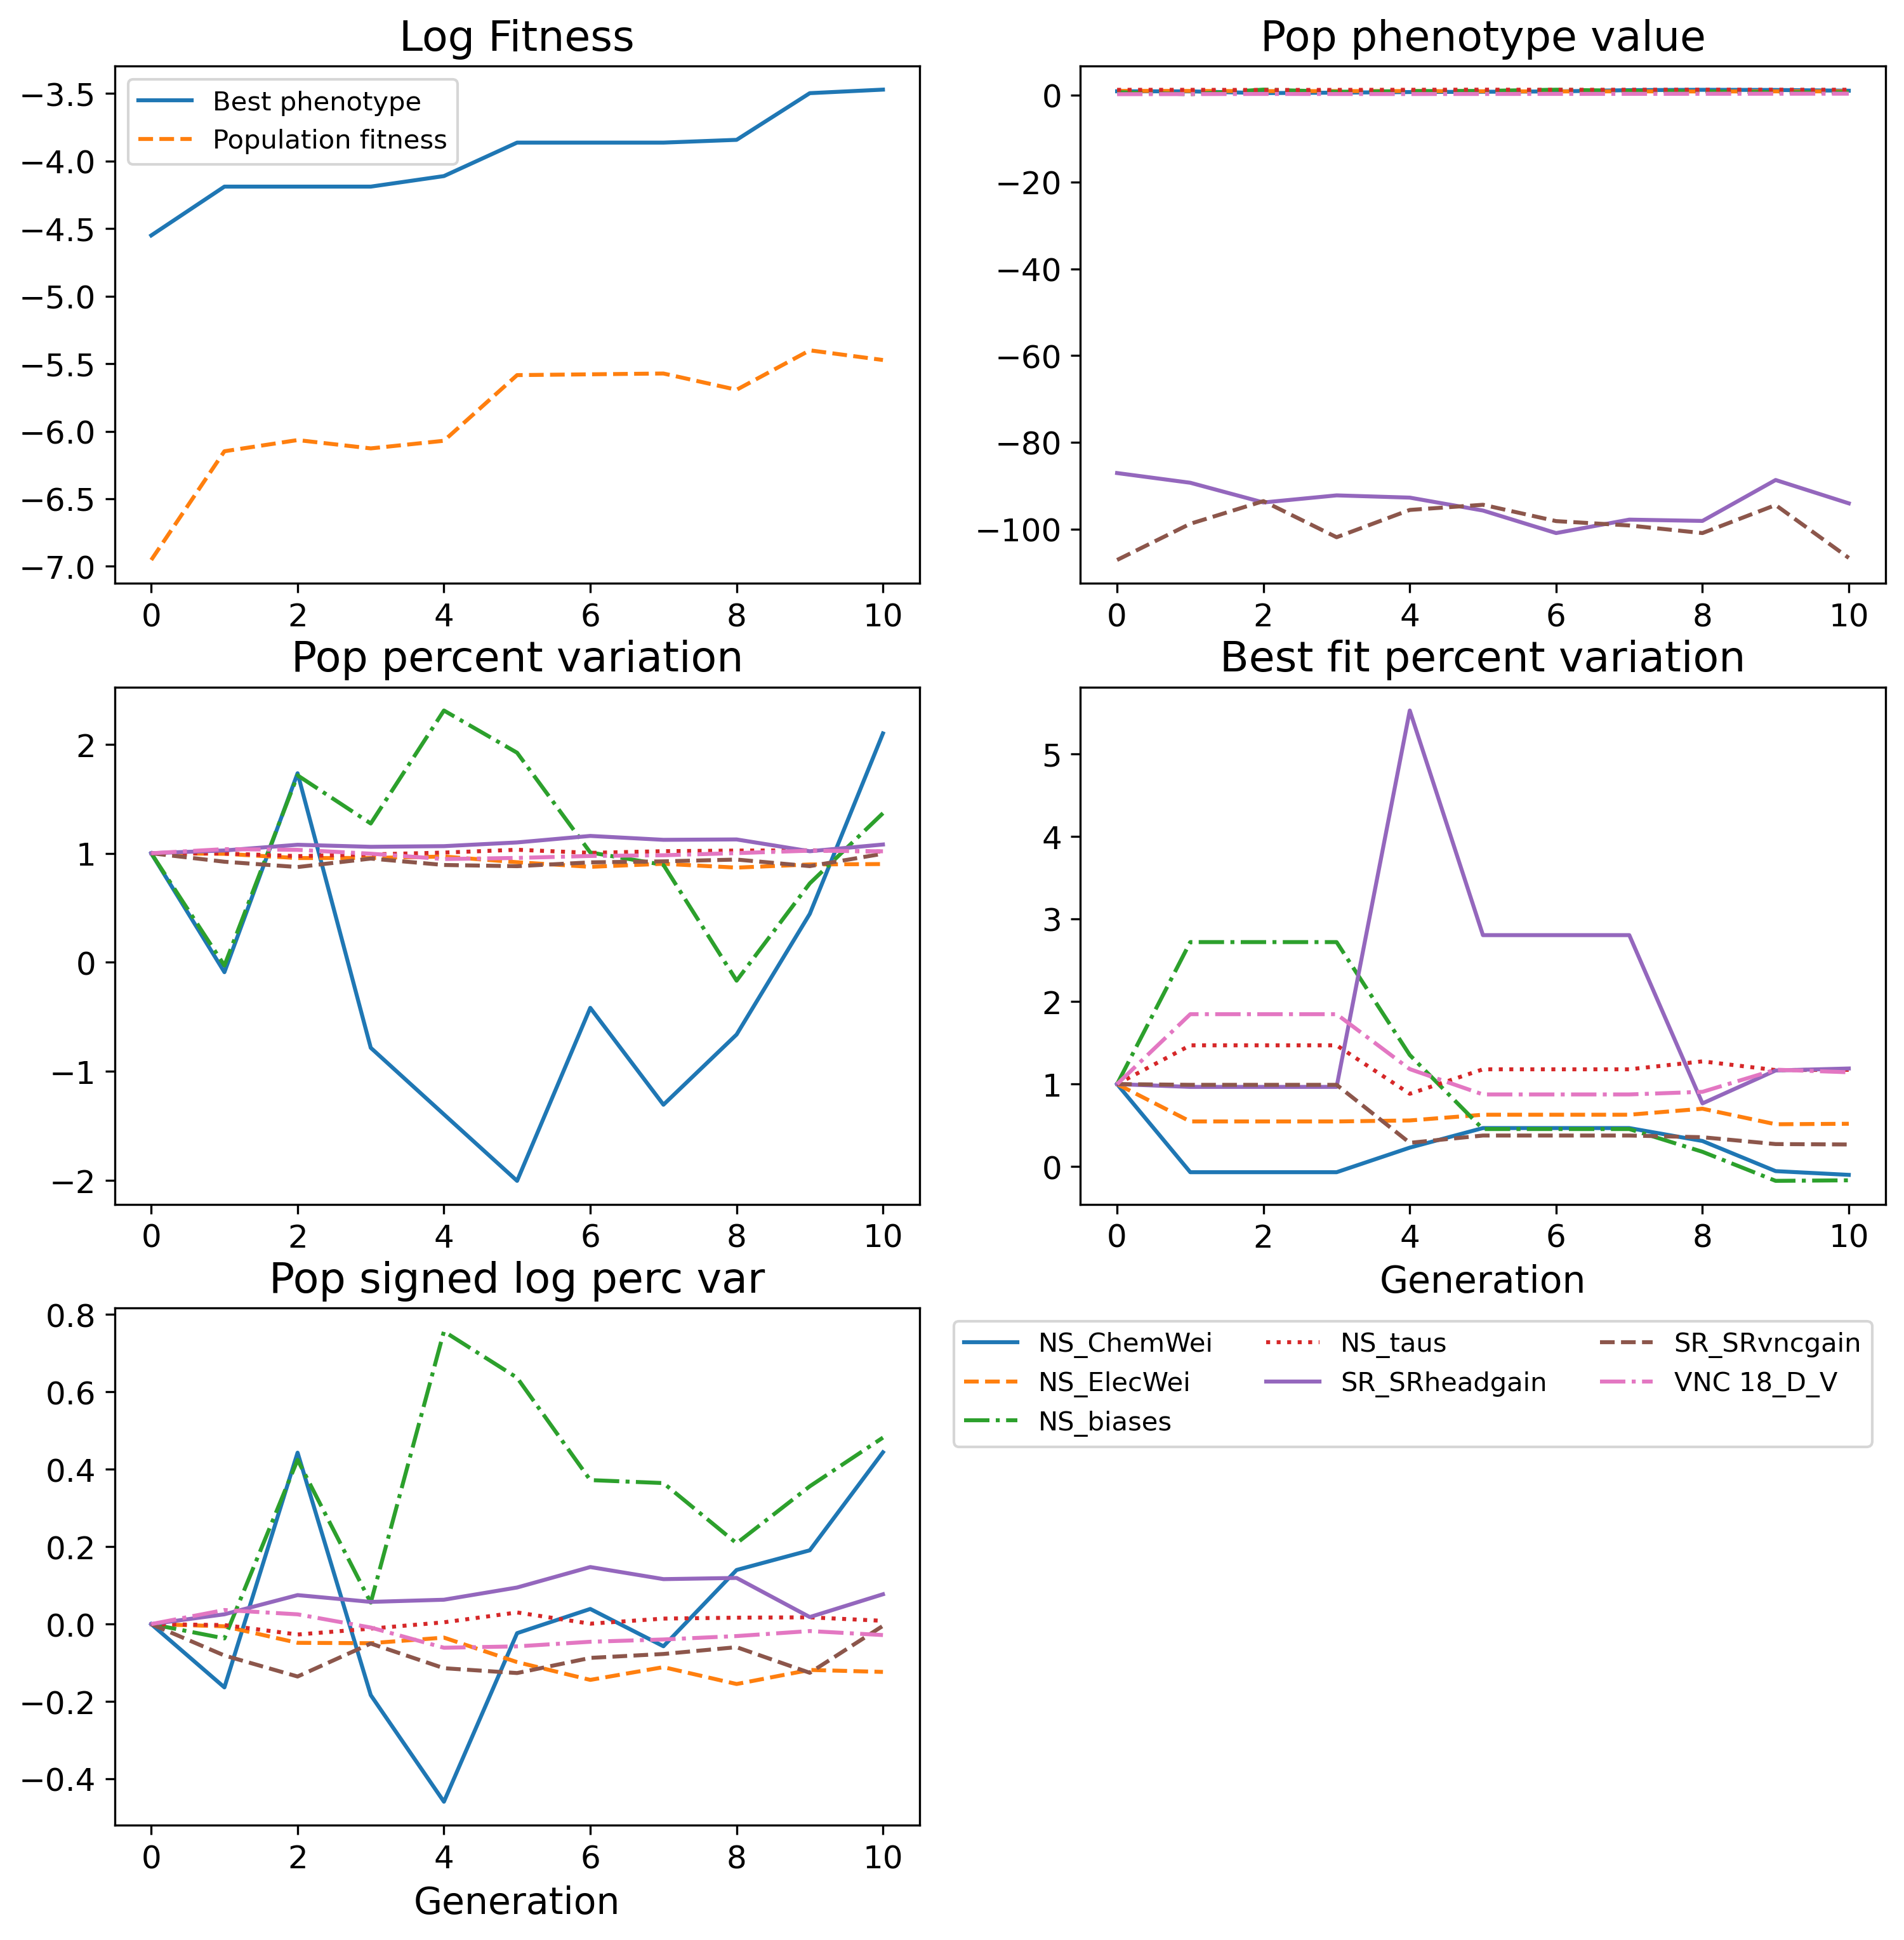

In [35]:
from IPython.display import Image, JSON
Image(filename=outputFolderName + '/Gridfig_av.png')

Run the evolution for a further 20 generations. Set evoAvLen parameter to smooth plots:

Further generations to be added: 20
Directory 'notebooks/example_evo' already exists and all the contents will be overwritten.
Parameter not found in worm_data.json
Parameter not found in worm_data.json
Parameter not found in worm_data.json
Parameter not found in worm_data.json
['Worm2D/main_osc', '--randomInitialState', '0', '--doOrigMuscInput', '0', '--doOrigSRInput', '0', '--doTestRun', '1', '-R', '124115', '-p', '36', '-d', '50.0', '-t', '10.0', '--maxgens', '20', '-sd', '60', '-st', '0', '--doevol', '1', '-cpt', '5', '--dorandinit', '0', '--donml', '0', '--folder', 'notebooks/example_evo', '--modelname', 'W2D18', '--domusc', '0', '-docpt', '1', '--evoType', 'Evo18']
jsonfile notebooks/example_evo/worm_data_worm.json
evotype Evo18
docpt 1
setFromCPT2 notebooks/example_evo/search.cpt
Resuming search
jsonfile notebooks/example_evo/worm_data_evo.json
jsonfile notebooks/example_evo/worm_data_evo.json
simrandseed 124115
running simulation sim

Loading activity data from: notebooks/examp

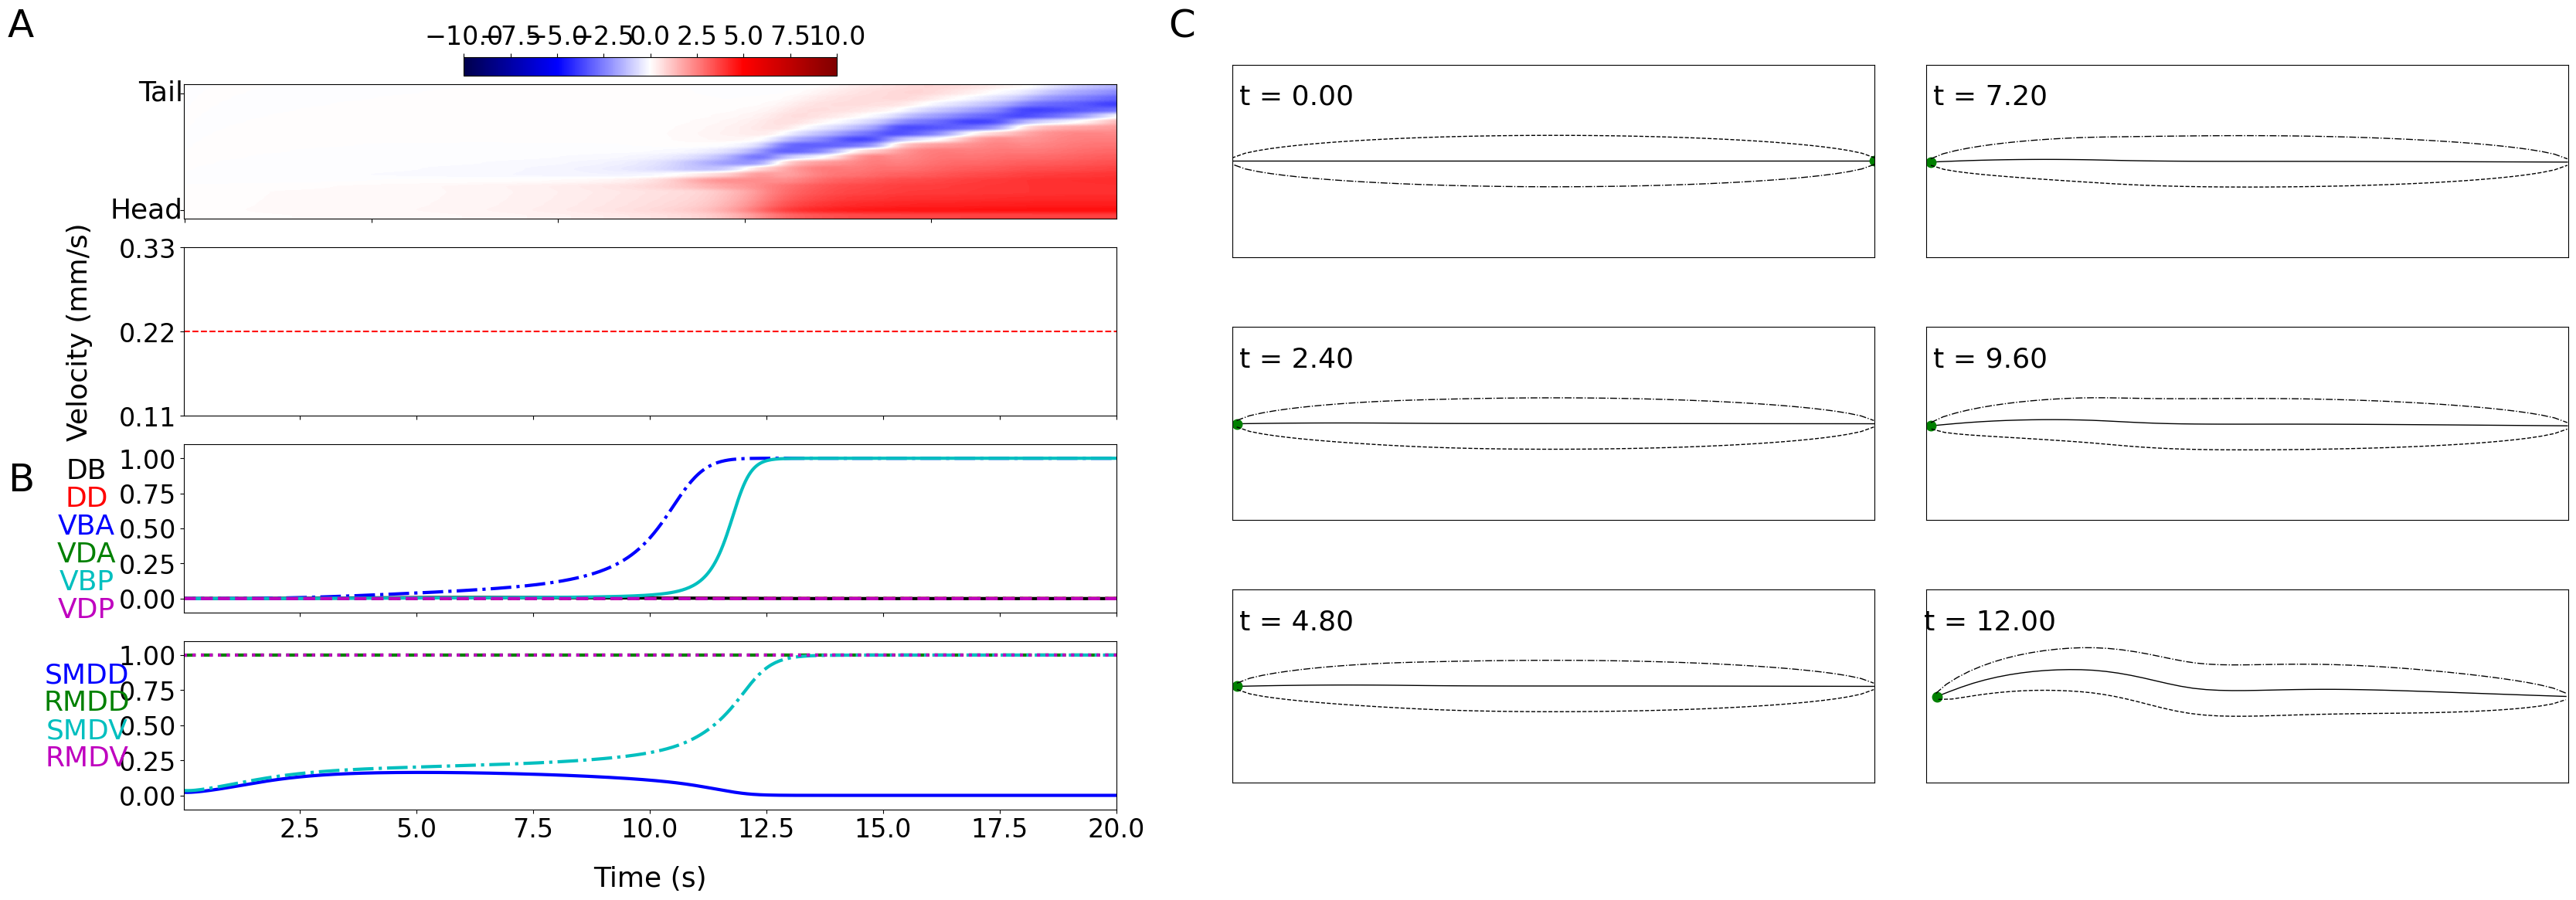

In [36]:
args['maxGens']=20 #run the optimization for ten more generations 
args['evoAvLen']=10 #plot moving average of evolution history figures  
print('Further generations to be added: ' + str(args['maxGens']))
run(**args)

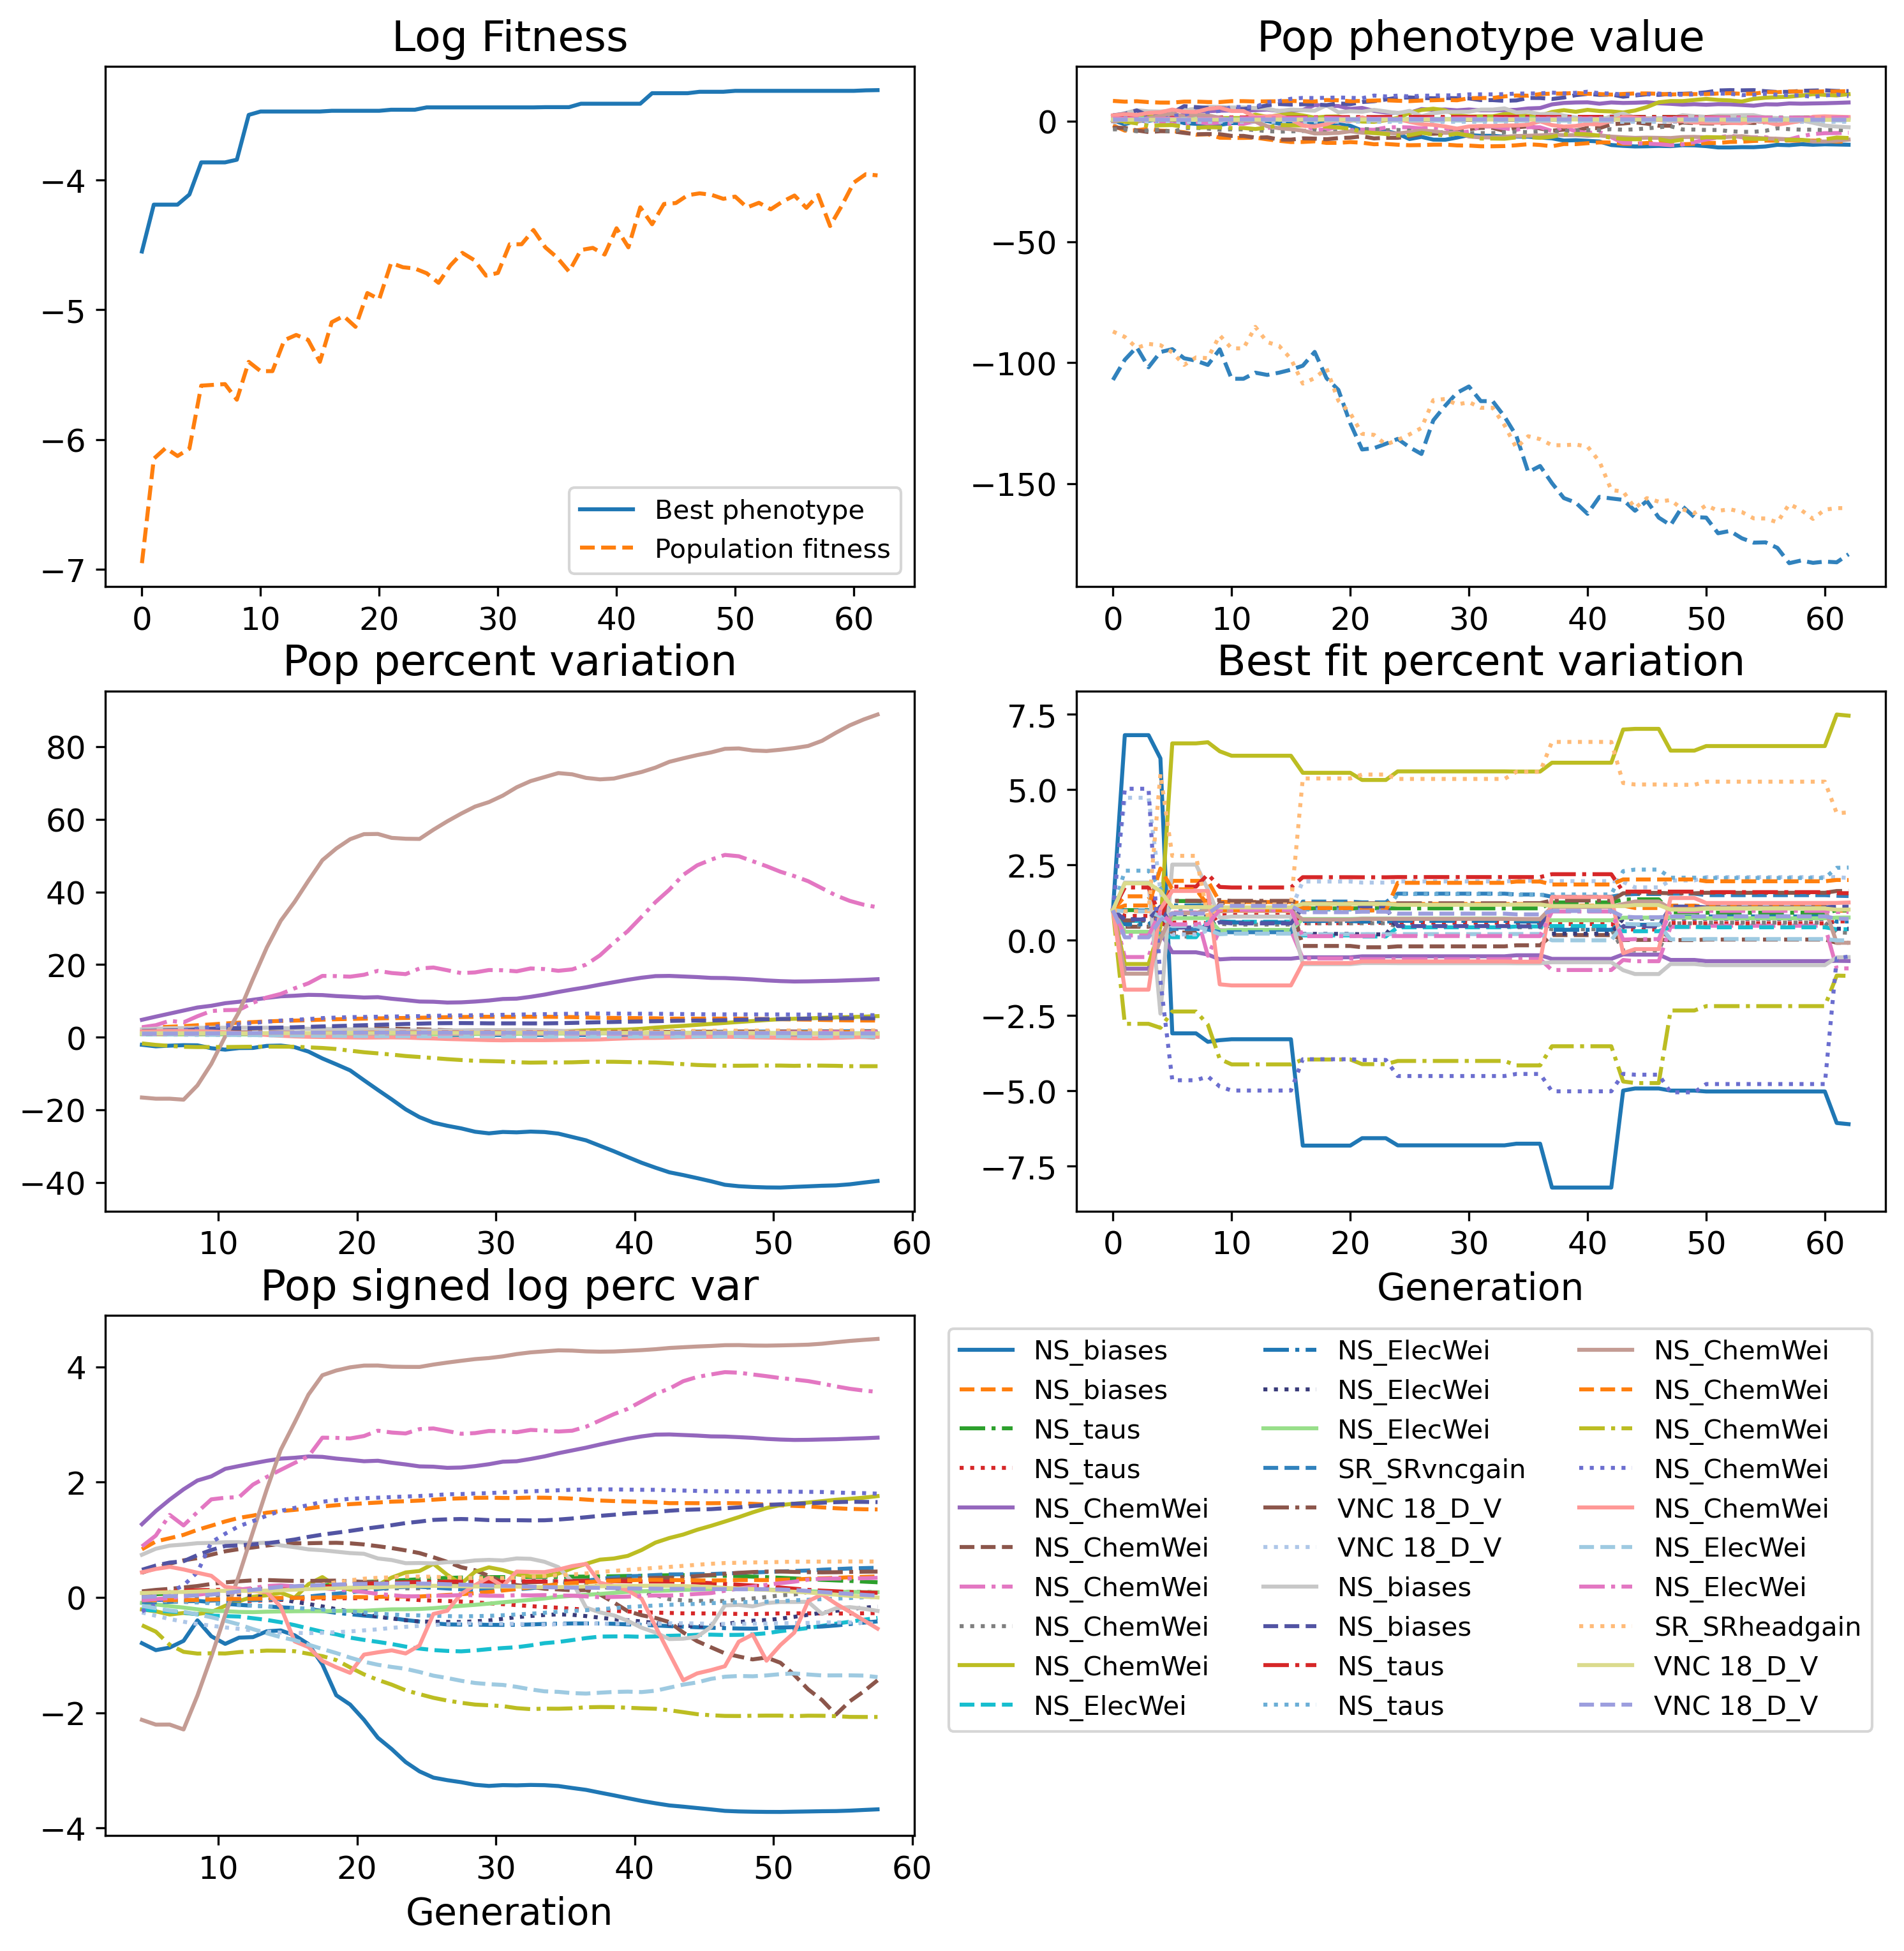

In [43]:
from IPython.display import Image, JSON
Image(filename=outputFolderName + '/Gridfig.png')

Display time series of simulation results of current best phenotype:

Examine the initial and current values for evolvable parameters:

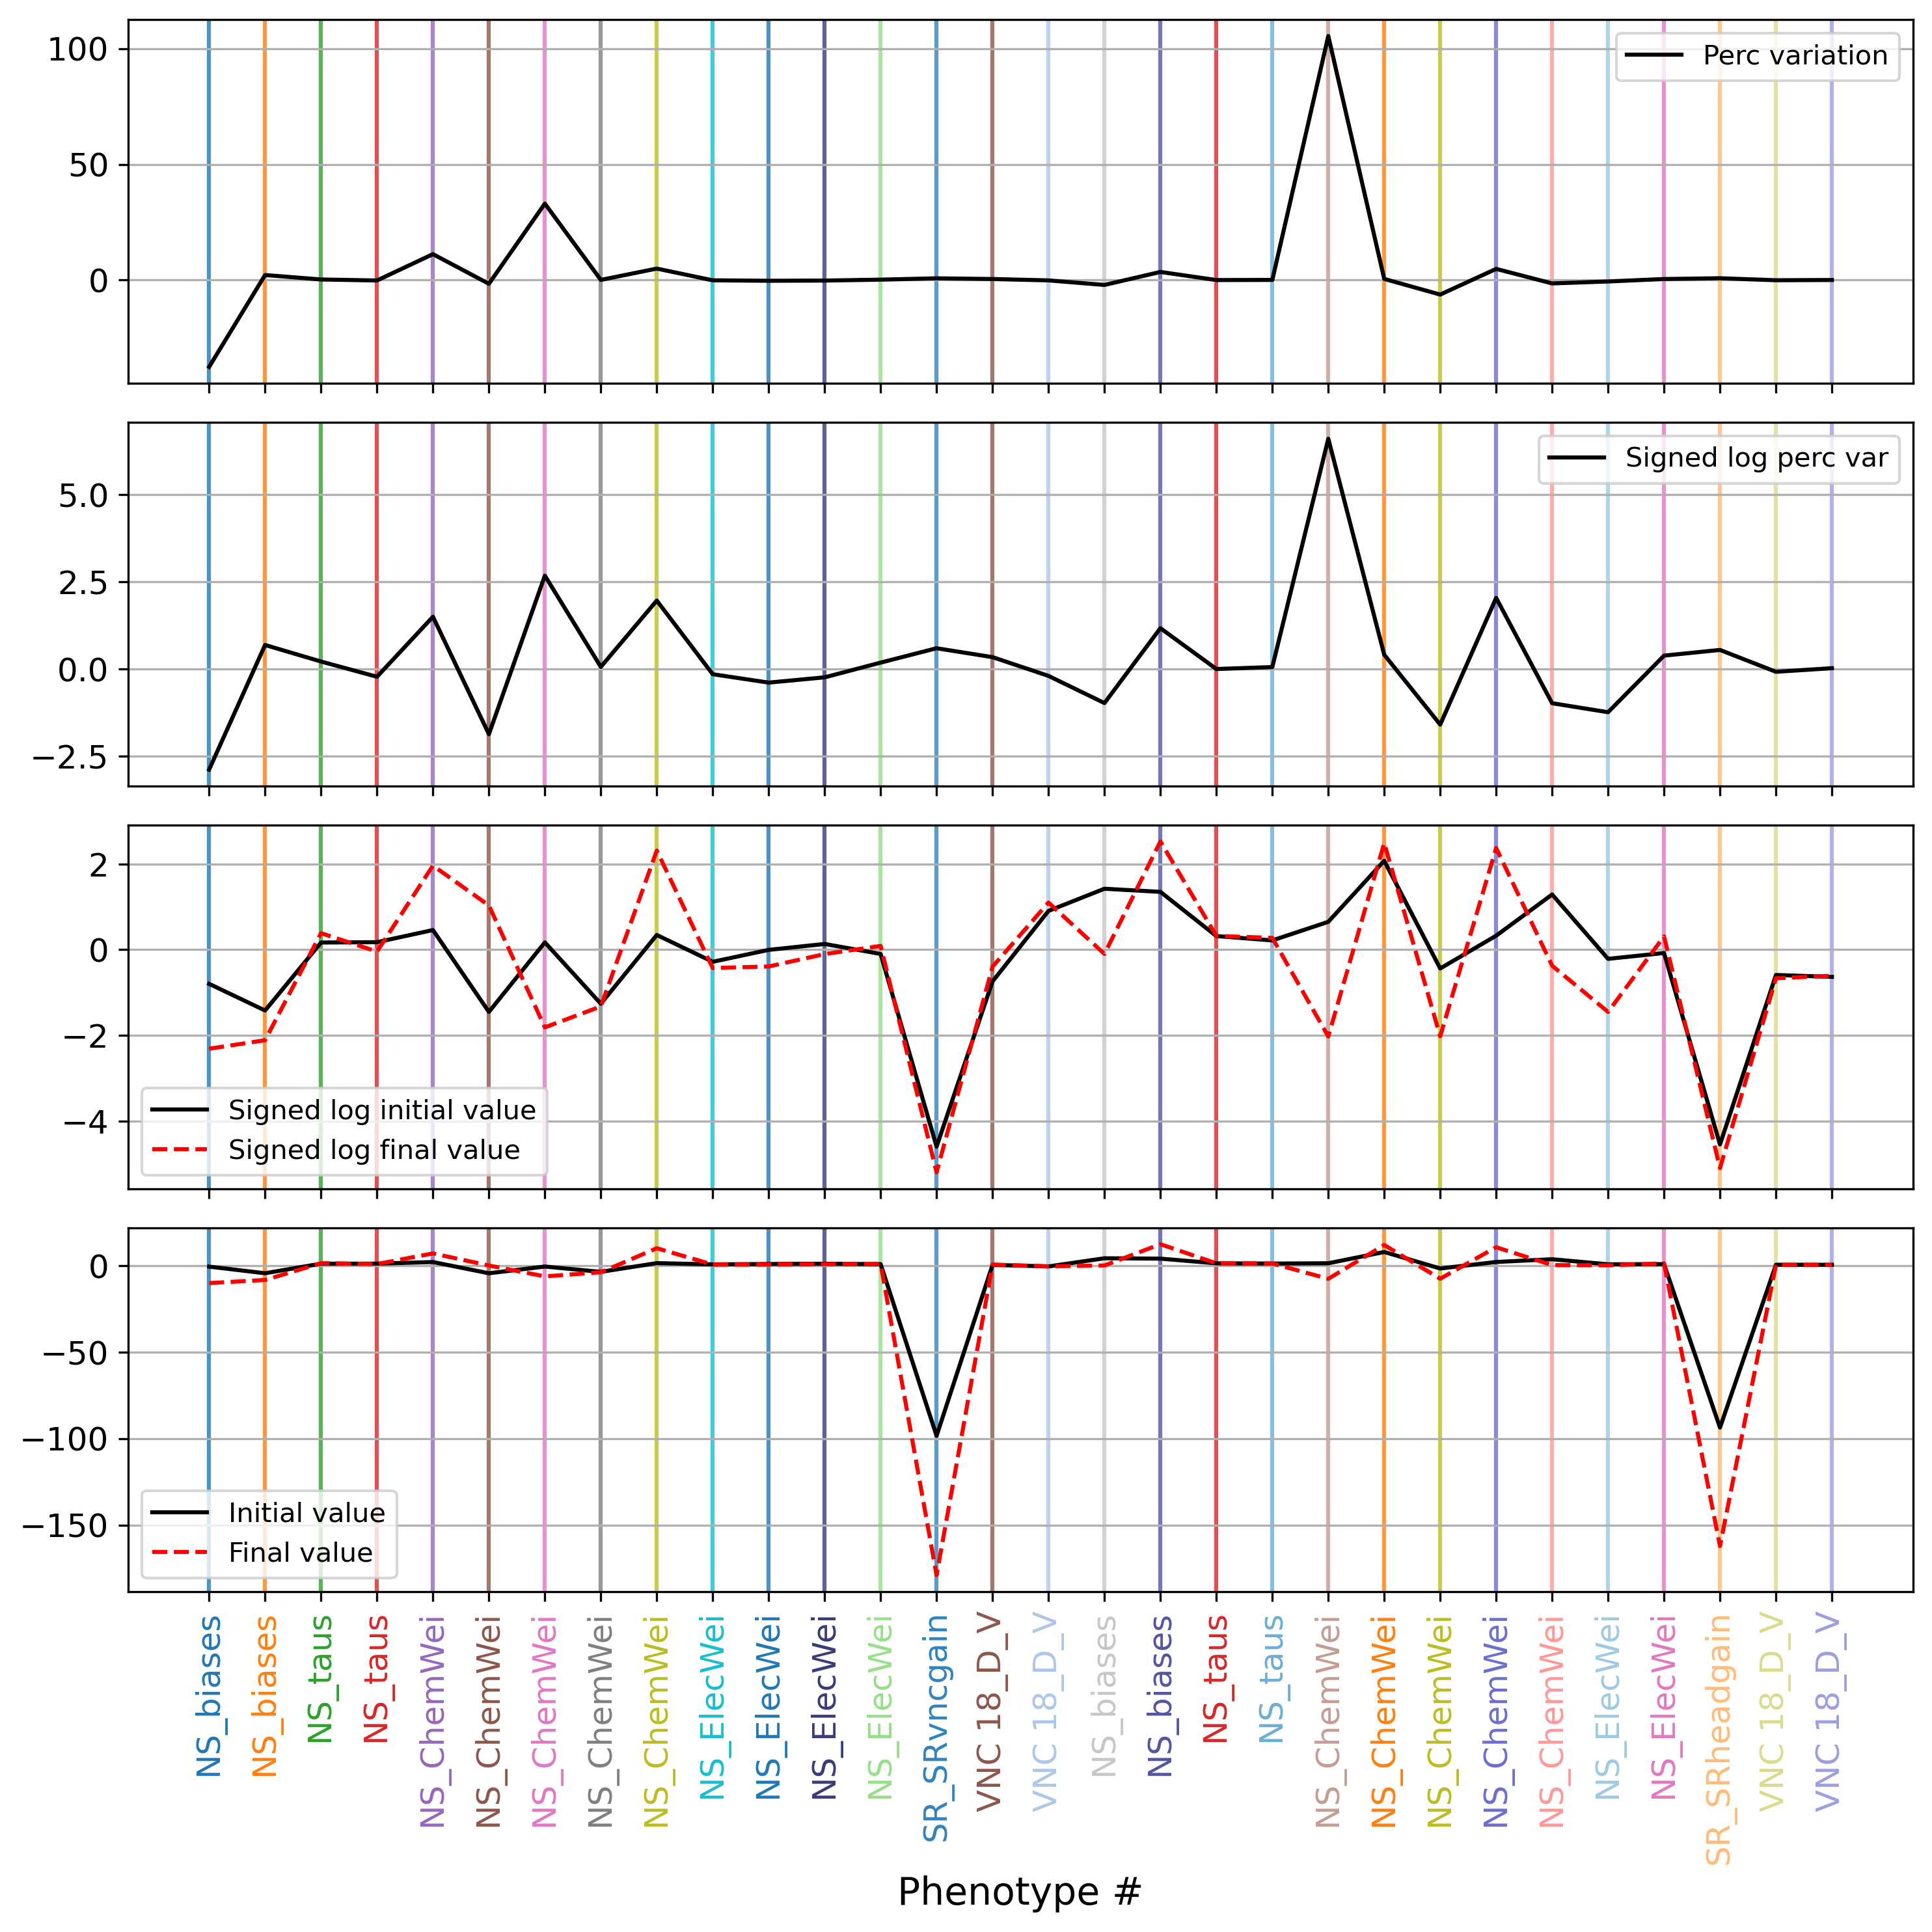

In [44]:
from IPython.display import Image, JSON
Image(filename=outputFolderName + '/Evolution_averages_redo_2.png')

Examine the initial and current values for averaged evolvable parameters:

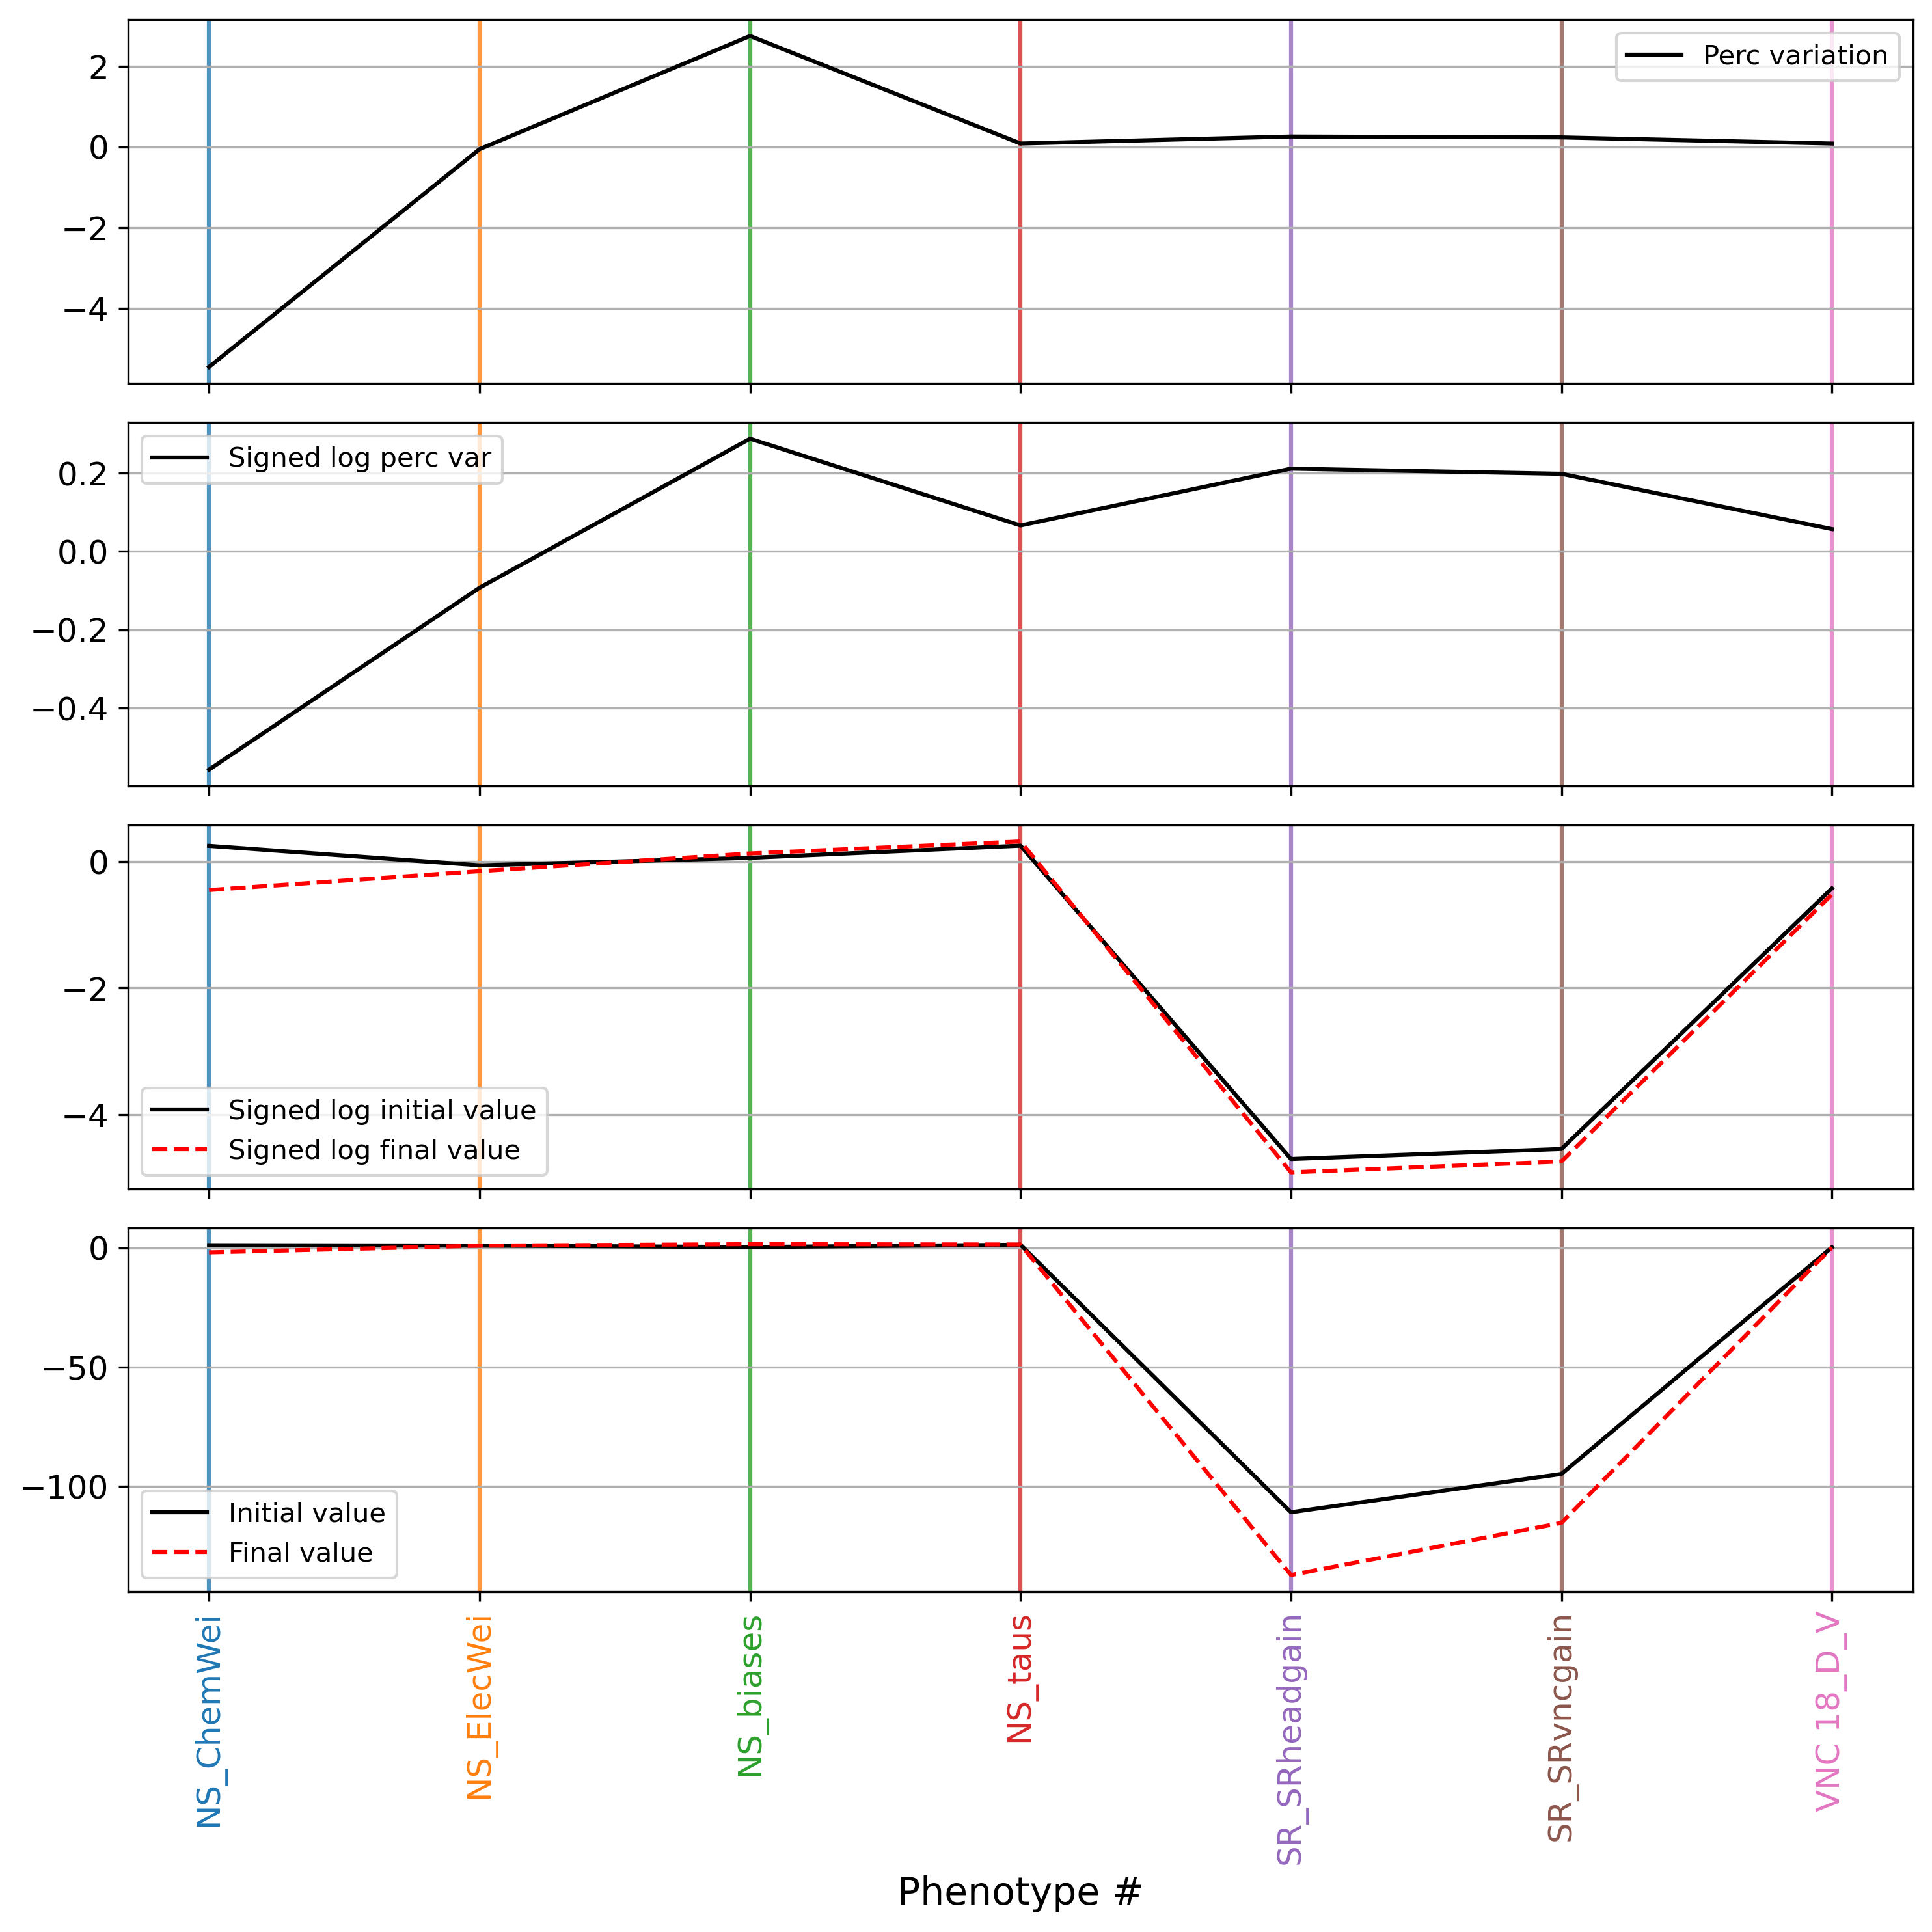

In [19]:
from IPython.display import Image, JSON
Image(filename=outputFolderName + '/Evolution_averages_redo.png')

Reload the simulation time series of the best phenotype:

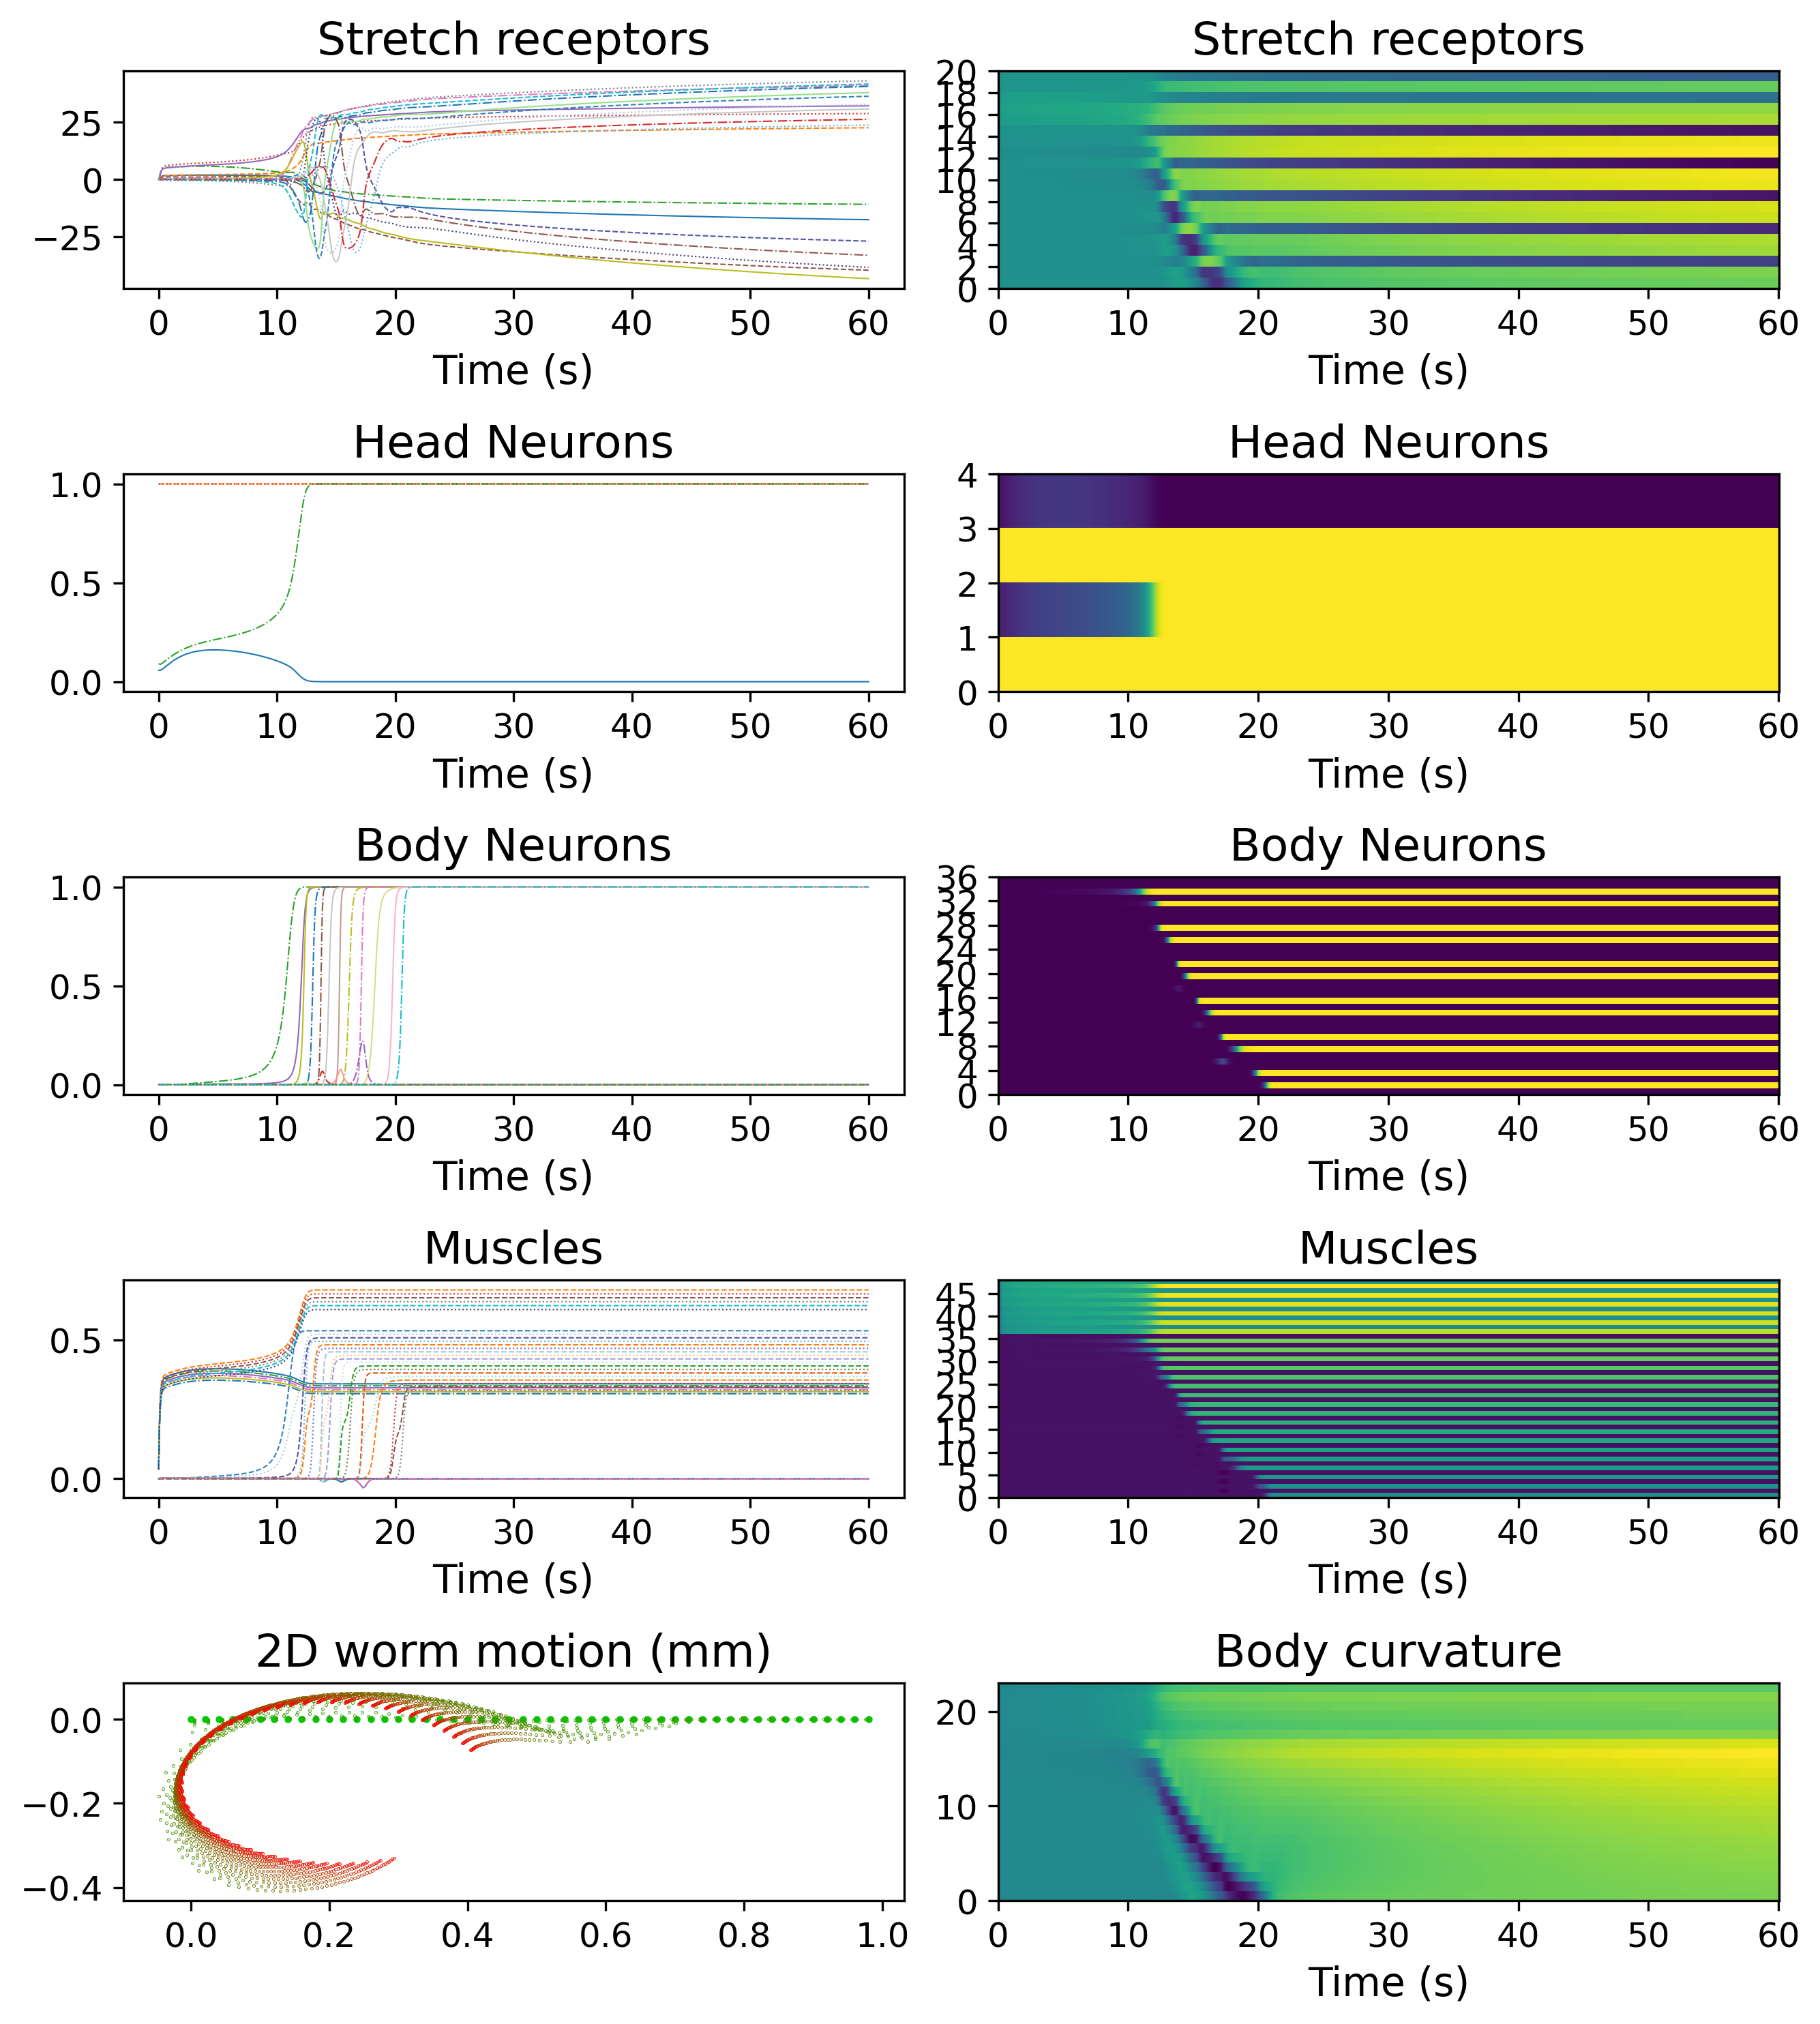

In [42]:
from IPython.display import Image, JSON
Image(filename=outputFolderName + '/ExampleActivity.png')

Run the evolution for a further 30 generations:

Further generations to be added: 30
Directory 'notebooks/example_evo' already exists and all the contents will be overwritten.
Parameter not found in worm_data.json
Parameter not found in worm_data.json
Parameter not found in worm_data.json
Parameter not found in worm_data.json
['Worm2D/main_osc', '--randomInitialState', '0', '--doOrigMuscInput', '0', '--doOrigSRInput', '0', '--doTestRun', '1', '-R', '124115', '-p', '36', '-d', '50.0', '-t', '10.0', '--maxgens', '30', '-sd', '60', '-st', '0', '--doevol', '1', '-cpt', '5', '--dorandinit', '0', '--donml', '0', '--folder', 'notebooks/example_evo', '--modelname', 'W2D18', '--domusc', '0', '-docpt', '1', '--evoType', 'Evo18']
jsonfile notebooks/example_evo/worm_data_worm.json
evotype Evo18
docpt 1
setFromCPT2 notebooks/example_evo/search.cpt
Resuming search
jsonfile notebooks/example_evo/worm_data_evo.json
jsonfile notebooks/example_evo/worm_data_evo.json
simrandseed 124115
running simulation sim

Loading activity data from: notebooks/examp

/home/adam/uclwork/CE_locomotion/load_data.py:121: RuntimeWarning: divide by zero encountered in log
  evol_data_diff_11 = sign(evol_data_diff_1) * np.log(np.abs(evol_data_diff_1))


Saved plot image to: notebooks/example_evo/EvolutionHistory.png
Saved plot image to: notebooks/example_evo/EvolutionHistoryMax.png
Saved plot image to: notebooks/example_evo/EvolutionHistoryMult.png
(63, 4)
Saved plot image to: notebooks/example_evo/FitnessHist.png
Evolvable
value
0
name
checkDict
['NS_biases', 'NS_biases', 'NS_taus', 'NS_taus', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ElecWei', 'NS_ElecWei', 'NS_ElecWei', 'NS_ElecWei', 'SR_SRvncgain', 'VNC 18_D_V', 'VNC 18_D_V', 'NS_biases', 'NS_biases', 'NS_taus', 'NS_taus', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ChemWei', 'NS_ElecWei', 'NS_ElecWei', 'SR_SRheadgain', 'VNC 18_D_V', 'VNC 18_D_V']
(63, 30)
(63, 30)
(63, 30)
(63, 30)
['NS_ChemWei', 'NS_ElecWei', 'NS_biases', 'NS_taus', 'SR_SRheadgain', 'SR_SRvncgain', 'VNC 18_D_V']
Saved plot image to: notebooks/example_evo/Evolution_averages_redo.png
Saved plot image to: notebooks/example_evo/Evolution_averages_redo_2.png


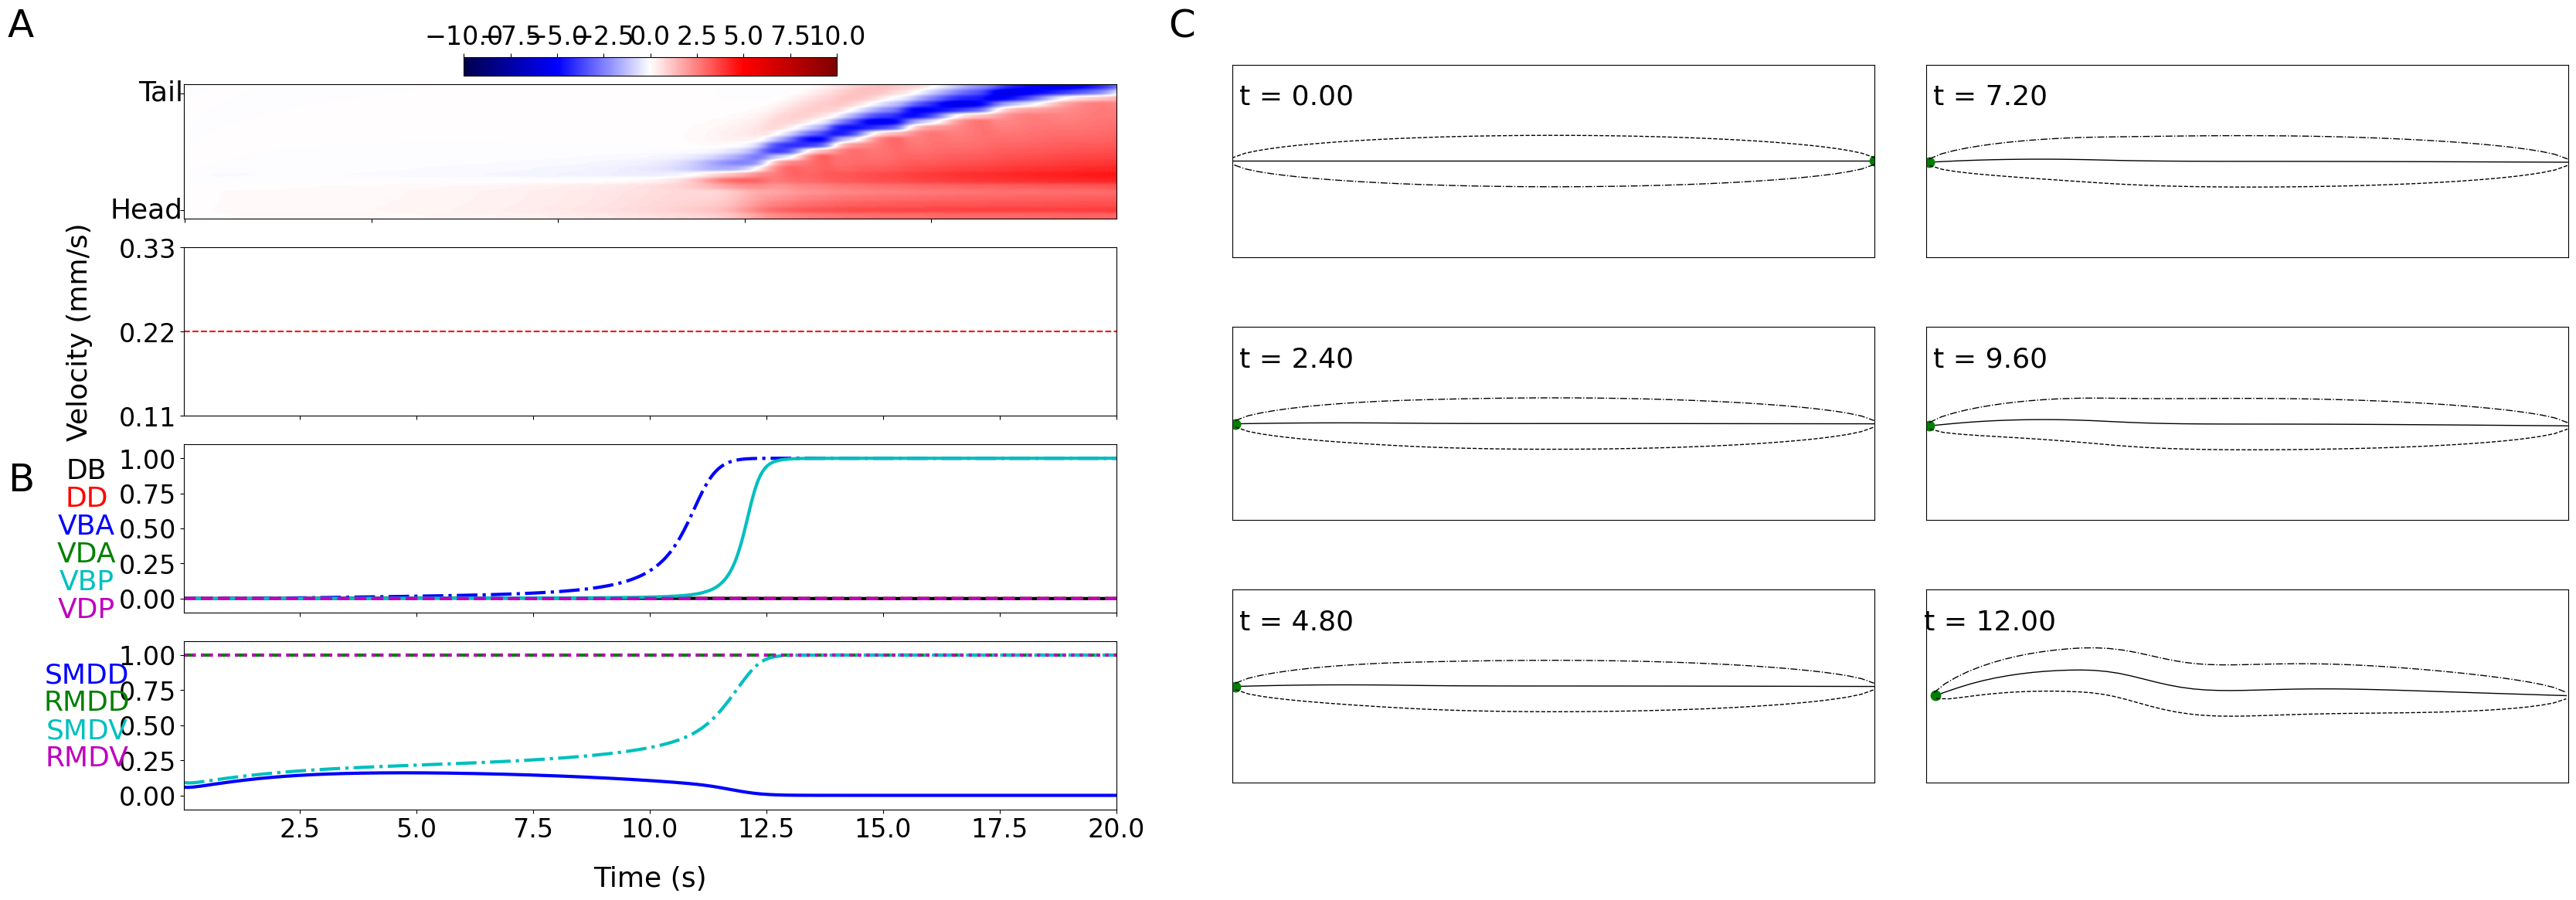

In [41]:
args['maxGens']=30 #run the optimization for ten more generations 
print('Further generations to be added: ' + str(args['maxGens']))
run(**args)